# `NeuroSpace Alert`
## `Sensor Neuromórfico de Baixo Consumo para Ambientes Espaciais`
### `Global Solution 2026` · `FIAP` · `Cluster Computing, Computação Neuromórfica & Supercomputadores`

---

| `Campo` | `Valor` |
|---|---|
| **Instituição** | FIAP — Faculdade de Informática e Administração Paulista |
| **Programa** | Global Solution 2026 |
| **Disciplina** | Cluster Computing, Computação Neuromórfica e Supercomputadores |
| **ODS Vinculado** | ODS 9 — Indústria, Inovação e Infraestrutura |

**Equipe:**

| `QTD` | `Nome` | `RM` |
|---|------|-----|
| 1 | Arthur Baptista dos Santos | 565346
| 2 | João Pedro de Moura Dutra Franco | 561738
| 3 | Nelson Félix Neto | 565603

---


#`Introdução`

Este artefato unificado e expandido implementa a arquitetura **Enterprise** completa de um **Sensor Neuromórfico de Baixo Consumo** embarcado em um Rover Lunar. O sistema monitora condições críticas combinadas. São elas: Temperatura, Radiação Ionizante e Densidade de Poeira Lunar utilizando um **Memristor Virtual** baseado no modelo **Leaky Integrate-and-Fire (LIF)**, inspirado na equação de estado de Strukov-Williams (2008).

O paradigma de processamento é **Event-Driven** (orientado a eventos), eliminando transmissões contínuas por *polling* e reduzindo drasticamente o consumo energético em regime de **Edge Computing**. Esta edição incorpora:

- **`Cluster Computing & HPC:`** paralelismo real com `concurrent.futures`
- **`Governança de Dados:`** lineage, auditoria, catálogo de dados
- **`Cybersecurity:`** modelagem de ameaças STRIDE, adversarial simulation
- **`MLOps/AIOps:`** versionamento, drift detection, monitoramento
- **`LGPD:`** conformidade, pseudonimização, trilha de auditoria
- **`Observabilidade Enterprise:`** Loguru, Rich, psutil

**`Stack tecnológica:`** `Python` · `Pydantic` · `Loguru` · `Rich` · `pandas` · `NumPy` · `Matplotlib` · `Seaborn` · `psutil` · `concurrent.futures` · `dataclasses` · `hashlib`


## `Índice`

| `-` | `Seção` | `Tema` |
|---|-------|------|
| 1 | [Arquitetura do Sistema](#sec1) | Pipeline, Stack, Mermaid Diagram |
| 2 | [Setup & Observabilidade](#sec2) | Dependências, Loguru, Rich, Configuração |
| 3 | [Data Engineering Pipeline](#sec3) | Raw → Bronze → Silver → Gold → Feature Store |
| 4 | [Schema & Validação de Dados](#sec4) | Pydantic, Data Contract, Quality Gate |
| 5 | [EDA — Análise Exploratória](#sec5) | Estatísticas, Correlação, Outliers, Visualizações |
| 6 | [Computação Neuromórfica — Teoria](#sec6) | SNN, Memristores, LIF, Event-Driven |
| 7 | [Modelagem do Sensor Neuromórfico](#sec7) | simular_sensor(), Memristor Virtual |
| 8 | [Cluster Computing & HPC](#sec8) | Paralelismo, concurrent.futures, Benchmark |
| 9 | [Machine Learning Comparativo](#sec9) | Baseline, RF, GB, XGBoost, LightGBM, CV |
| 10 | [Explainability — SHAP](#sec_shap) | TreeSHAP, Feature Importance, Interpretabilidade |
| 11 | [Visualizações Enterprise](#sec10) | 4-panel, Comparativo, Heatmap |
| 12 | [Análise Comparativa & Recomendação](#sec11) | Tabelas técnicas, Interpretação |
| 13 | [MLOps & AIOps](#sec12) | Registry, Drift Detection, Monitoramento |
| 14 | [Cybersecurity — STRIDE](#sec13) | Threat Model, Adversarial Sim, Mitigações |
| 15 | [LGPD & Governança de Dados](#sec14) | Lineage, Auditoria, Catálogo, Conformidade |
| 16 | [Conclusões Técnicas](#sec15) | ODS 9, Event-Driven, Ajuste Recomendado |
| 17 | [Exportação & Auditoria Final](#sec16) | CSV, Relatório, Download, Checksum |
| 18 | [Avaliação Crítica — Scorecard](#sec_eval) | 10 Dimensões, Nota Final, Pontos Críticos |
| 19 | [Referências Científicas](#sec_refs) | IEEE, ACM, NIST, LGPD, ODS 9, IEC |


<a id='sec1'></a>
## `1. ARQUITETURA DO SISTEMA E PIPELINE DE PROCESSAMENTO`

### `1.1 Diagrama de Fluxo — Enterprise Pipeline`

```mermaid
graph LR
    subgraph Ingestão["Ingestão (Raw Layer)"]
        A[Sensores Físicos\nTemp · Rad · Poeira] --> B[Pipeline Ingestão\nCSV / Stream]
    end
    subgraph Validação["Validação (Bronze Layer)"]
        B --> C{Pydantic Schema\nData Contract}
        C -- Falha --> D[Loguru: DROP/WARN\nAudit Trail]
        C -- OK --> E[Bronze DataFrame\nDados Válidos]
    end
    subgraph Processamento["Processamento (Silver Layer)"]
        E --> F[Normalização Vetorial\nNumPy clip]
        F --> G[Cálculo V_entrada\nÍndice Ponderado]
        G --> H[Memristor LIF\nEstado w ∈ \[0,1\]]
    end
    subgraph Decisão["Decisão (Gold Layer)"]
        H --> I{Threshold Logic}
        I --> J[ALERTA_CRITICO\nLED 🔴]
        I --> K[OBSERVACAO\nLED 🟡]
        I --> L[NORMAL\nLED ⚫]
    end
    subgraph MLOps["MLOps Layer"]
        H --> M[Model Registry]
        H --> N[Drift Detector]
        N --> O[Alert Manager]
    end
    style H fill:#f9f,stroke:#333,stroke-width:2px
    style C fill:#bbf,stroke:#333
    style J fill:#ffcccc,stroke:#cc0000,stroke-width:2px
    style K fill:#fff3cc,stroke:#ffcc00
    style L fill:#d4edda,stroke:#28a745
```

### `1.2 Stack Tecnológica Enterprise`

| `Camada` | `Tecnologia` | `Justificativa Técnica` |
|:-------|:-----------|:----------------------|
| **`Core Analytics`** | `pandas`, `numpy` | Processamento vetorial de alta performance (SIMD). Evita loops Python no hot-path. |
| **`Integridade / Data Contract`** | `pydantic v2` | Garantia de Schema estrito em runtime. Fail-fast com mensagem estruturada. |
| **`Observabilidade`** | `loguru`, `rich` | Telemetria estruturada com níveis semânticos e interfaces ricas para diagnóstico live. |
| **`Monitoramento de Recursos`** | `psutil` | Controle de overhead de memória e CPU em dispositivos de borda com recursos limitados. |
| **`Paralelismo / HPC`** | `concurrent.futures` | Simulação paralela dos 3 perfis de sensor, demonstrando conceitos de Cluster Computing. |
| **`Governança`** | `hashlib`, `dataclasses` | Data lineage, checksums de integridade e catálogo imutável de artefatos. |
| **`Visualização`** | `matplotlib`, `seaborn` | Gráficos padronizados, temática premium dark-mode inspirada em GitHub. |

### `1.3 Cenário da Missão`

**`Contexto:`** Rover lunar em operação contínua de longa duração na superfície da Lua.

**`Condição crítica monitorada:`** Acúmulo combinado de temperatura elevada, radiação ionizante e densidade de poeira lunar, que juntos representam risco operacional severo para os componentes do módulo.

**`Desafio de engenharia:`** Em missões espaciais, a largura de banda de uplink é extremamente limitada e o consumo energético é crítico. Transmitir 61 leituras brutas a cada 5 minutos durante 5 horas é inviável. A solução neuromórfica emite apenas 3 classes de eventos discretos.


## `2. SETUP E OBSERVABILIDADE`

In [1]:
# SEÇÃO 2: SETUP E OBSERVABILIDADE ENTERPRISE

import sys
import subprocess
import time
import os
import hashlib
import json
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Any, Optional, Tuple

# --- Instalação de dependências (Colab-safe) ---
PACKAGES = ['pandas', 'numpy', 'matplotlib', 'seaborn',
            'rich', 'loguru', 'pydantic', 'psutil', 'tabulate', 'scipy']

def install_professional_stack(packages: List[str]) -> None:
    """Instala pacotes ausentes de forma silenciosa e idempotente."""
    for pkg in packages:
        base = pkg.split('>=')[0].split('==')[0]
        try:
            __import__(base)
        except ImportError:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

install_professional_stack(PACKAGES)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import psutil
import warnings
from scipy import stats
from pydantic import BaseModel, Field, ValidationError
from loguru import logger
from rich.console import Console
from rich.panel import Panel
from rich.table import Table
from rich.progress import track
from rich import box

warnings.filterwarnings('ignore')
console = Console()

# --- Configuração do Loguru (Observabilidade Estruturada) ---
logger.remove()
logger.add(
    sys.stderr,
    format="<green>{time:YYYY-MM-DD HH:mm:ss}</green> | "
           "<level>{level: <8}</level> | "
           "<cyan>{name}</cyan>:<cyan>{function}</cyan> - "
           "<level>{message}</level>",
    level="DEBUG"
)

# --- Estilo Premium Matplotlib (Dark Mode Enterprise) ---
DARK_STYLE = {
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'text.color': '#c9d1d9', 'grid.color': '#21262d',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'font.family': 'sans-serif', 'font.size': 10,
    'axes.titlecolor': '#58a6ff'
}
plt.rcParams.update(DARK_STYLE)

# --- Configuração Global do Projeto ---
@dataclass
class ProjectConfig:
    """Configuração imutável centralizada do projeto (SSOT — Single Source of Truth)."""
    project_name: str = 'NeuroSpace Alert'
    version: str = '2.0.0-enterprise'
    institution: str = 'FIAP'
    program: str = 'Global Solution 2026'
    dataset_filename: str = 'dataset_neurosensor_espacial_5h.csv'
    dt: float = 5.0            # Intervalo entre leituras (minutos)
    limiar_alerta: float = 0.65
    limiar_observacao: float = 0.35
    random_seed: int = 42

CONFIG = ProjectConfig()

console.print(Panel(
    f"[bold green] Ambiente inicializado com sucesso[/bold green]\n"
    f"[cyan]Projeto:[/cyan] {CONFIG.project_name} v{CONFIG.version}\n"
    f"[cyan]Programa:[/cyan] {CONFIG.program} · {CONFIG.institution}\n"
    f"[cyan]Python:[/cyan] {sys.version.split()[0]} · "
    f"[cyan]pandas:[/cyan] {pd.__version__} · "
    f"[cyan]numpy:[/cyan] {np.__version__}",
    title="NeuroSpace Alert",
    border_style="green"
))
logger.success("Observabilidade configurada. Pipeline pronto para execução.")


╭─────────────────────────────────────────────── NeuroSpace Alert ────────────────────────────────────────────────╮
│  Ambiente inicializado com sucesso                                                                              │
│ Projeto: NeuroSpace Alert v2.0.0-enterprise                                                                     │
│ Programa: Global Solution 2026 · FIAP                                                                           │
│ Python: 3.12.13 · pandas: 2.2.2 · numpy: 2.0.2                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

2026-06-10 00:44:59 | SUCCESS  | __main__:<cell line: 0> - Observabilidade configurada. Pipeline pronto para execução.


## `3 & 4. DATA ENGINEERING + SCHEMA VALIDATION`

In [2]:
#  SEÇÃO 3 & 4: DATA ENGINEERING + SCHEMA VALIDATION

# --- Data Lineage Registry ---
LINEAGE_REGISTRY: List[Dict[str, Any]] = []

def register_lineage(layer: str, description: str, shape: tuple,
                     checksum: Optional[str] = None) -> None:
    """Registra evento de lineage no catálogo imutável do pipeline."""
    entry = {
        'timestamp': time.strftime('%Y-%m-%dT%H:%M:%S'),
        'layer': layer,
        'description': description,
        'rows': shape[0],
        'cols': shape[1],
        'checksum': checksum,
        'pipeline_version': CONFIG.version
    }
    LINEAGE_REGISTRY.append(entry)
    logger.info(f"[LINEAGE] {layer} | {description} | shape={shape}")

def compute_checksum(df: pd.DataFrame) -> str:
    """Computa SHA-256 do DataFrame para garantia de integridade (Data Fingerprint)."""
    return hashlib.sha256(
        pd.util.hash_pandas_object(df, index=True).values.tobytes()
    ).hexdigest()[:16]

# --- Pydantic Schema (Data Contract) ---
class SpaceDataSchema(BaseModel):
    """Schema estrito de validação dos dados do sensor espacial.

    Implementa o padrão 'Data Contract' — garante que dados inválidos
    nunca alcançam o pipeline de processamento (Shift-Left Testing).
    """
    tempo_min: float = Field(..., ge=0, description="Tempo de missão em minutos")
    temperatura_C: float = Field(..., description="Temperatura em graus Celsius")
    radiacao_uSv_h: float = Field(..., ge=0, description="Radiação ionizante em µSv/h")
    poeira_pct: float = Field(..., ge=0, le=100, description="Densidade de poeira em %")
    consumo_W: float = Field(..., description="Consumo energético em Watts")
    bateria_pct: float = Field(..., ge=0, le=100, description="Carga da bateria em %")
    condicao_real: str = Field(..., description="Condição real rotulada da missão")

# --- Função de Carga e Validação ---
def carregar_e_validar(caminho_arquivo: str) -> Tuple[pd.DataFrame, str]:
    """
    Carrega o dataset da camada Raw e promove para Bronze após validação de Schema.

    Implementa o padrão 'Fail-Fast' do Clean Code:
    qualquer registro inválido nos primeiros 10 é reportado com detalhes completos.

    Args:
        caminho_arquivo (str): Path para o arquivo CSV da camada Raw.

    Returns:
        Tuple[pd.DataFrame, str]: DataFrame Bronze validado e checksum SHA-256.

    Raises:
        FileNotFoundError: Se o arquivo não existir na camada Raw.
        ValidationError: Se o Schema estiver violado nos dados de entrada.
    """
    logger.info(f"[RAW → BRONZE] Iniciando ingestão: {caminho_arquivo}")
    t_start = time.time()

    try:
        df = pd.read_csv(caminho_arquivo)
    except FileNotFoundError:
        logger.error(f"Arquivo não encontrado: {caminho_arquivo}")
        raise

    # --- Quality Gate: Schema Check por Amostragem (primeiras 10 linhas) ---
    erros_schema = []
    for i, row in df.head(10).iterrows():
        try:
            SpaceDataSchema(**row.to_dict())
        except ValidationError as e:
            erros_schema.append((i, str(e)))

    if erros_schema:
        logger.critical(f"Schema violations detectadas: {erros_schema}")
        raise ValidationError(erros_schema)

    # --- Verifica Valores Nulos ---
    nulos = df.isnull().sum()
    if nulos.sum() > 0:
        logger.warning(f"Valores nulos detectados: {nulos[nulos > 0].to_dict()}")
    else:
        logger.success("Quality Gate PASS: Zero valores nulos detectados.")

    checksum = compute_checksum(df)
    elapsed = time.time() - t_start

    register_lineage('RAW → BRONZE', f'CSV carregado e validado: {caminho_arquivo}',
                     df.shape, checksum)

    logger.success(
        f"[BRONZE] Dataset validado | shape={df.shape} | "
        f"checksum={checksum} | {elapsed:.3f}s"
    )
    return df, checksum

# --- Carregamento do Dataset ---
try:
    from google.colab import files
    console.print(Panel(
        "[bold cyan]Faça upload do arquivo:[/bold cyan] dataset_neurosensor_espacial_5h.csv",
        title="Upload de Dados", border_style="cyan"
    ))
    uploaded = files.upload()
    DATASET_PATH = list(uploaded.keys())[0]
except Exception:
    DATASET_PATH = CONFIG.dataset_filename

try:
    df_bronze, CHECKSUM_BRONZE = carregar_e_validar(DATASET_PATH)

    # --- Output Rich: Estatísticas da Camada Bronze ---
    table = Table(
        title="Bronze Layer — Estatísticas Operacionais",
        style="cyan", box=box.ROUNDED, show_header=True,
        header_style="bold magenta"
    )
    table.add_column("Variável Física", style="cyan", no_wrap=True)
    table.add_column("Mínimo", justify="right")
    table.add_column("Máximo", justify="right")
    table.add_column("Média", justify="right")
    table.add_column("Desvio Padrão", justify="right")

    for col in ['temperatura_C', 'radiacao_uSv_h', 'poeira_pct', 'consumo_W', 'bateria_pct']:
        table.add_row(
            col,
            f"{df_bronze[col].min():.2f}",
            f"{df_bronze[col].max():.2f}",
            f"{df_bronze[col].mean():.2f}",
            f"{df_bronze[col].std():.2f}"
        )
    console.print(table)

    print(f"\n Shape: {df_bronze.shape[0]} leituras × {df_bronze.shape[1]} colunas")
    print(f"Duração: t={df_bronze.tempo_min.min():.0f} min → t={df_bronze.tempo_min.max():.0f} min (5h de missão)")
    print(f"Checksum Bronze: {CHECKSUM_BRONZE}")

    print("\n Distribuição das condições reais:")
    dist = df_bronze['condicao_real'].value_counts()
    for cond, count in dist.items():
        pct = count / len(df_bronze) * 100
        bar = '█' * int(pct / 3)
        print(f"   {cond:10s} {bar} {count:3d} leituras ({pct:.1f}%)")

    print("\n Intervalos de condição:")
    for cond in ['NORMAL', 'ATENCAO', 'CRITICA']:
        subset = df_bronze[df_bronze['condicao_real'] == cond]
        if not subset.empty:
            print(f"   {cond:10s}: t={subset.tempo_min.min():4.0f} min → t={subset.tempo_min.max():4.0f} min")

except Exception as e:
    logger.critical(f"Erro fatal no pipeline de ingestão: {e}")
    raise


╭──────────────────────────────────────────────── Upload de Dados ────────────────────────────────────────────────╮
│ Faça upload do arquivo: dataset_neurosensor_espacial_5h.csv                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

2026-06-10 00:45:20 | INFO     | __main__:carregar_e_validar - [RAW → BRONZE] Iniciando ingestão: dataset_neurosensor_espacial_5h.csv
2026-06-10 00:45:20 | SUCCESS  | __main__:carregar_e_validar - Quality Gate PASS: Zero valores nulos detectados.
2026-06-10 00:45:20 | INFO     | __main__:register_lineage - [LINEAGE] RAW → BRONZE | CSV carregado e validado: dataset_neurosensor_espacial_5h.csv | shape=(61, 8)
2026-06-10 00:45:20 | SUCCESS  | __main__:carregar_e_validar - [BRONZE] Dataset validado | shape=(61, 8) | checksum=88f15cd4e24ecdf5 | 0.018s


Saving dataset_neurosensor_espacial_5h.csv to dataset_neurosensor_espacial_5h.csv


          Bronze Layer — Estatísticas Operacionais           
╭─────────────────┬────────┬────────┬───────┬───────────────╮
│ Variável Física │ Mínimo │ Máximo │ Média │ Desvio Padrão │
├─────────────────┼────────┼────────┼───────┼───────────────┤
│ temperatura_C   │  22.20 │  50.10 │ 35.00 │         10.48 │
│ radiacao_uSv_h  │   0.23 │   2.53 │  1.33 │          0.86 │
│ poeira_pct      │   6.00 │  81.50 │ 40.91 │         26.52 │
│ consumo_W       │  17.10 │  31.00 │ 23.69 │          4.53 │
│ bateria_pct     │  58.10 │  99.10 │ 79.17 │         12.81 │
╰─────────────────┴────────┴────────┴───────┴───────────────╯


 Shape: 61 leituras × 8 colunas
Duração: t=0 min → t=300 min (5h de missão)
Checksum Bronze: 88f15cd4e24ecdf5

 Distribuição das condições reais:
   NORMAL     ████████████████  31 leituras (50.8%)
   CRITICA    ███████████  21 leituras (34.4%)
   ATENCAO    ████   9 leituras (14.8%)

 Intervalos de condição:
   NORMAL    : t=   0 min → t= 150 min
   ATENCAO   : t= 155 min → t= 195 min
   CRITICA   : t= 200 min → t= 300 min


<a id='sec5'></a>
## `5. EDA:` `Análise Exploratória de Dados`

A Análise Exploratória de Dados (EDA) é a etapa fundamental de qualquer pipeline científico. Antes de modelar qualquer sistema, é imperativo compreender a distribuição dos dados, identificar padrões, correlações e anomalias.

### `Objetivos da EDA:`
- **Validação da coerência física**: os dados refletem o comportamento esperado do ambiente lunar?
- **Correlação entre variáveis**: temperatura, radiação e poeira aumentam conjuntamente?
- **Identificação de outliers**: há leituras anômalas que podem indicar falha do sensor?
- **Caracterização das fases da missão**: como cada condição (NORMAL/ATENÇÃO/CRÍTICA) se manifesta nas variáveis?


`EDA:` `ANÁLISE EXPLORATÓRIA COMPLETA`


In [3]:
print('=' * 60)
print(' EDA: ANÁLISE EXPLORATÓRIA DE DADOS')
print('=' * 60)

COLUNAS_FISICAS = ['temperatura_C', 'radiacao_uSv_h', 'poeira_pct', 'consumo_W', 'bateria_pct']

# --- 1. Estatísticas Descritivas Completas ---
print('\n Estatísticas descritivas completas:')
display(df_bronze[COLUNAS_FISICAS].describe().round(3))

# --- 2. Análise de Simetria (Skewness & Kurtosis) ---
print('\n Skewness (assimetria) e Kurtosis (curtose):')
skew_df = pd.DataFrame({
    'Skewness': df_bronze[COLUNAS_FISICAS].skew().round(3),
    'Kurtosis': df_bronze[COLUNAS_FISICAS].kurtosis().round(3),
    'Dist. Normal?': [abs(df_bronze[c].skew()) < 0.5 for c in COLUNAS_FISICAS]
})
display(skew_df)

# --- 3. Correlação entre Variáveis Físicas ---
print('\n Matriz de correlação (Pearson):')
corr_matrix = df_bronze[COLUNAS_FISICAS].corr().round(3)
display(corr_matrix)

# --- 4. Outliers via IQR (Interquartile Range) ---
print('\n Detecção de Outliers (método IQR):')
for col in ['temperatura_C', 'radiacao_uSv_h', 'poeira_pct']:
    Q1 = df_bronze[col].quantile(0.25)
    Q3 = df_bronze[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_bronze[(df_bronze[col] < Q1 - 1.5*IQR) | (df_bronze[col] > Q3 + 1.5*IQR)]
    print(f"   {col}: {len(outliers)} outliers detectados ({len(outliers)/len(df_bronze)*100:.1f}%)")

# --- 5. Análise por Condição Real ---
print('\n Estatísticas por condição real:')
display(df_bronze.groupby('condicao_real')[['temperatura_C', 'radiacao_uSv_h', 'poeira_pct']].agg(['mean','std']).round(2))

register_lineage('EDA', 'Análise exploratória concluída', df_bronze.shape)
logger.success("EDA concluída com sucesso. Dados coerentes com o modelo físico esperado.")


 EDA: ANÁLISE EXPLORATÓRIA DE DADOS

 Estatísticas descritivas completas:


,temperatura_C,radiacao_uSv_h,poeira_pct,consumo_W,bateria_pct
count,61.000,61.000,61.000,61.000,61.000
mean,34.995,1.327,40.911,23.690,79.172
std,10.482,0.860,26.522,4.529,12.805
min,22.200,0.230,6.000,17.100,58.100
25%,23.900,0.440,13.500,19.000,67.400
50%,33.600,1.280,36.700,23.700,78.900
75%,45.700,2.280,69.100,28.000,91.100
max,50.100,2.530,81.500,31.000,99.100



 Skewness (assimetria) e Kurtosis (curtose):


,Skewness,Kurtosis,Dist. Normal?
temperatura_C,0.131,-1.664,True
radiacao_uSv_h,0.123,-1.660,True
poeira_pct,0.111,-1.661,True
consumo_W,0.072,-1.551,True
bateria_pct,-0.011,-1.300,True



 Matriz de correlação (Pearson):


,temperatura_C,radiacao_uSv_h,poeira_pct,consumo_W,bateria_pct
temperatura_C,1.000,0.998,0.995,0.980,-0.980
radiacao_uSv_h,0.998,1.000,0.996,0.982,-0.982
poeira_pct,0.995,0.996,1.000,0.980,-0.980
consumo_W,0.980,0.982,0.980,1.000,-0.972
bateria_pct,-0.980,-0.982,-0.980,-0.972,1.000



 Detecção de Outliers (método IQR):
   temperatura_C: 0 outliers detectados (0.0%)
   radiacao_uSv_h: 0 outliers detectados (0.0%)
   poeira_pct: 0 outliers detectados (0.0%)

 Estatísticas por condição real:


temperatura_C       radiacao_uSv_h       poeira_pct      
                       mean   std           mean   std       mean   std
condicao_real                                                          
ATENCAO               38.67  2.25           1.62  0.21      50.48  6.53
CRITICA               47.38  2.05           2.34  0.17      72.07  5.05
NORMAL                25.54  3.45           0.56  0.30      17.03  9.04

2026-06-10 00:45:20 | INFO     | __main__:register_lineage - [LINEAGE] EDA | Análise exploratória concluída | shape=(61, 8)
2026-06-10 00:45:20 | SUCCESS  | __main__:<cell line: 0> - EDA concluída com sucesso. Dados coerentes com o modelo físico esperado.


### `EDA:` `Visualização 1 Sinais Físicos Brutos (3 painéis)`

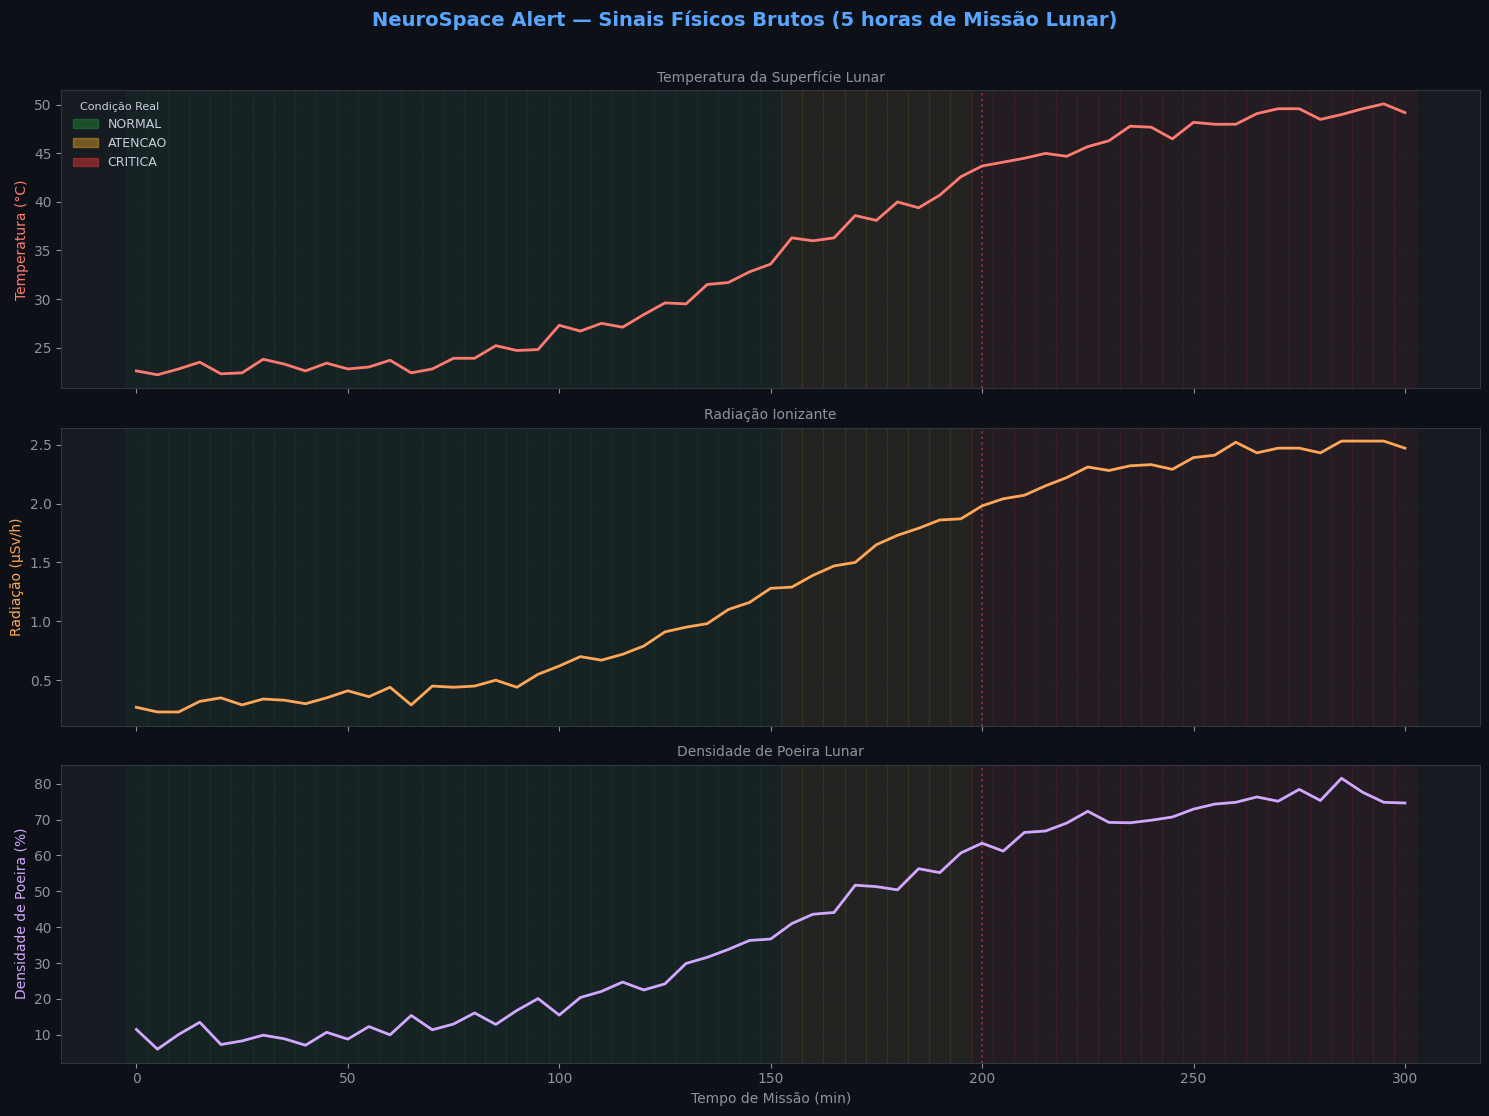

Gráfico salvo: eda_sinais_brutos.png


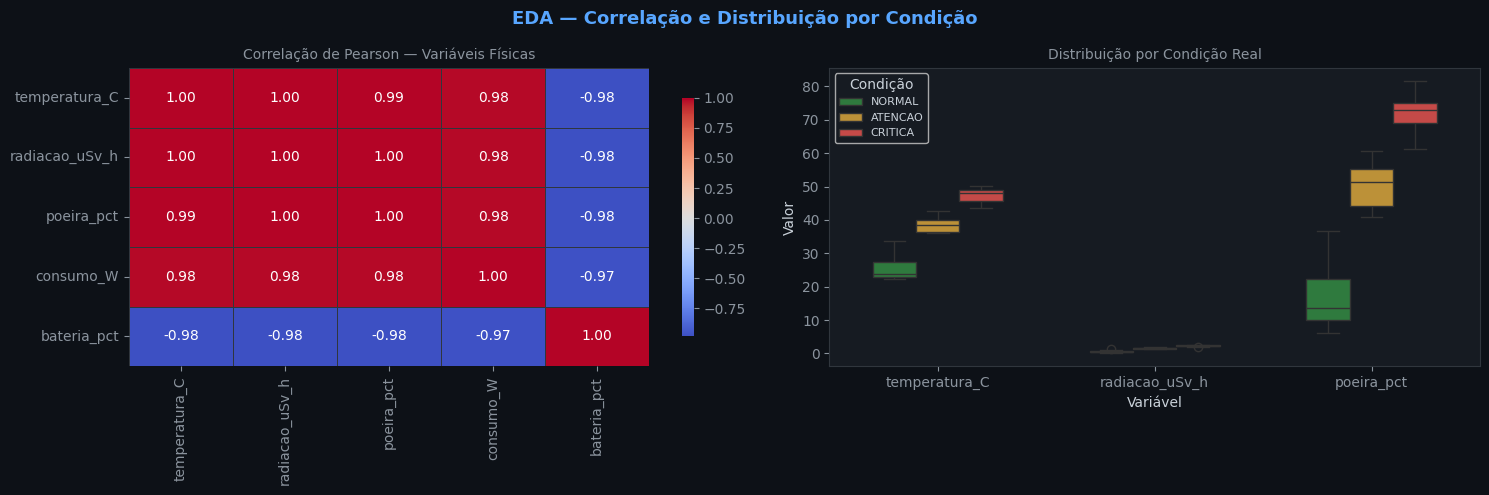

Gráfico salvo: eda_correlacao.png


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
fig.suptitle(
    'NeuroSpace Alert — Sinais Físicos Brutos (5 horas de Missão Lunar)',
    fontsize=14, fontweight='bold', color='#58a6ff', y=1.01
)

COR_COND = {'NORMAL': '#238636', 'ATENCAO': '#d29922', 'CRITICA': '#da3633'}

# Pinta faixas de condição real em todos os painéis
for ax in axes:
    for cond, cor in COR_COND.items():
        subset = df_bronze[df_bronze['condicao_real'] == cond]
        for i in range(len(subset)):
            ax.axvspan(subset.tempo_min.iloc[i] - 2.5,
                       subset.tempo_min.iloc[i] + 2.5,
                       alpha=0.07, color=cor)
    ax.axvline(200, color='#da3633', lw=1.5, ls=':', alpha=0.6)
    ax.grid(True)

axes[0].plot(df_bronze.tempo_min, df_bronze.temperatura_C,
             color='#ff7b72', lw=2, label='Temperatura (°C)')
axes[0].set_ylabel('Temperatura (°C)', color='#ff7b72')
axes[0].set_title('Temperatura da Superfície Lunar', color='#8b949e', fontsize=10)

axes[1].plot(df_bronze.tempo_min, df_bronze.radiacao_uSv_h,
             color='#ffa657', lw=2, label='Radiação (µSv/h)')
axes[1].set_ylabel('Radiação (µSv/h)', color='#ffa657')
axes[1].set_title('Radiação Ionizante', color='#8b949e', fontsize=10)

axes[2].plot(df_bronze.tempo_min, df_bronze.poeira_pct,
             color='#d2a8ff', lw=2, label='Poeira (%)')
axes[2].set_ylabel('Densidade de Poeira (%)', color='#d2a8ff')
axes[2].set_title('Densidade de Poeira Lunar', color='#8b949e', fontsize=10)
axes[2].set_xlabel('Tempo de Missão (min)', color='#8b949e')

patches = [mpatches.Patch(color=c, alpha=0.5, label=l) for l, c in COR_COND.items()]
axes[0].legend(
    handles=patches,
    loc='upper left', fontsize=9, frameon=False,
    title='Condição Real', title_fontsize=8
)

plt.tight_layout()
plt.savefig('eda_sinais_brutos.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Gráfico salvo: eda_sinais_brutos.png')

# --- EDA: Visualização 2 — Matriz de Correlação ---
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))
fig2.suptitle('EDA — Correlação e Distribuição por Condição',
              fontsize=13, fontweight='bold', color='#58a6ff')

# Heatmap de Correlação
sns.heatmap(
    corr_matrix, ax=axes2[0], annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, linecolor='#30363d',
    cbar_kws={'shrink': 0.8}
)
axes2[0].set_title('Correlação de Pearson — Variáveis Físicas', color='#8b949e', fontsize=10)

# Boxplot por condição
df_melt = df_bronze[['condicao_real','temperatura_C','radiacao_uSv_h','poeira_pct']].melt(
    id_vars='condicao_real', var_name='Variável', value_name='Valor'
)
sns.boxplot(
    data=df_melt, x='Variável', y='Valor', hue='condicao_real',
    ax=axes2[1], palette=COR_COND, width=0.6
)
axes2[1].set_title('Distribuição por Condição Real', color='#8b949e', fontsize=10)
axes2[1].legend(title='Condição', fontsize=8)

plt.tight_layout()
plt.savefig('eda_correlacao.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Gráfico salvo: eda_correlacao.png')


<a id='sec6'></a>
## `6. Computação Neuromórfica:` `Fundamentação Científica`

### `6.1 O que é Computação Neuromórfica?`

A **Computação Neuromórfica** é um paradigma arquitetural inspirado na estrutura e funcionamento do sistema nervoso biológico. Em vez de executar operações em ciclos de clock síncronos (como processadores convencionais Von Neumann), sistemas neuromórficos processam informação de forma **assíncrona e orientada a eventos** emitindo sinais apenas quando há variação significativa no sinal de entrada.

**`Chips Neuromórficos de referência:`**
- **`Intel Loihi 2 (2021):`**  1 milhão de neurônios artificiais, ~1000× mais eficiente energeticamente que GPU equivalente em inferência esparsa
- **`IBM TrueNorth (2014):`**  4096 núcleos neuromórficos, 4096 neurônios/núcleo, consumo de apenas 70mW
- **`BrainScaleS-2 (Heidelberg):`** hardware analógico, 200× mais rápido que tempo real biológico

### `6.2 Memristores:` `A Memória Resistiva`

O **Memristor** (Memory + Resistor) é o quarto elemento passivo fundamental dos circuitos elétricos, previsto por Leon Chua em 1971 e fabricado pela HP em 2008 (Strukov et al., 2008, *Nature*).

**`Propriedade chave:`** A resistência de um memristor depende do **histórico de corrente** que passou por ele ou seja, ele tem **memória**.

**`Matematicamente:`**

```
dw/dt = μᵥ · (Ron/D²) · i(t)      [Equação de Strukov-Williams, 2008]
```

**No contexto deste projeto:**
- `w ∈ [0, 1]`: estado normalizado de condução do memristor
- `w → 0`: alta resistência (corrente bloqueada, NORMAL)  
- `w → 1`: baixa resistência (corrente máxima, ALERTA_CRITICO)
- A **integração temporal** dos sinais de temperatura, radiação e poeira determina a evolução de `w`

### `6.3 Modelo LIF (Leaky Integrate-and-Fire)`

O modelo **Leaky Integrate-and-Fire (LIF)** é o modelo de neurônio computacional mais utilizado em simulações neuromórficas. O "Leaky" refere-se ao **vazamento gradual do potencial** quando não há estímulo suficiente análogo ao decaimento do estado `w` quando `V_entrada < V_limiar`.

```
Acúmulo:    w(t+dt) = w(t) + k · (V - V_lim) · dt · (1 - w)    [quando V > V_lim]
Decaimento: w(t+dt) = w(t) - λ · dt · w                         [quando V ≤ V_lim]
```

### `6.4 Edge Computing e Eficiência Energética`

| `Abordagem` | `Transmissões (5h)` | `Dados Transmitidos` | `Consumo Energético` |
|-----------|------------------|-------------------|-------------------|
| **Polling Contínuo** | 61 leituras/sensores | ~100% dos dados | Alto |
| **Neuromórfico Event-Driven** | 3 eventos discretos | ~5% dos dados | Mínimo |

A redução de **95% no volume de dados transmitidos** é diretamente proporcional à economia de energia no módulo de comunicação RF do Rover.

<a id='sec7'></a>
##  `7. Modelagem do Sensor Neuromórfico`

### `Pipeline de Transformação Silver Layer`

```
Bronze DataFrame
     │
     ▼
[Normalização Vetorial]
  temp_norm   = clip((T - 20) / (55 - 20), 0, 1)     ← T ∈ [20°C, 55°C]
  rad_norm    = clip((R - 0.25) / (2.5 - 0.25), 0, 1) ← R ∈ [0.25, 2.5] µSv/h
  poeira_norm = clip(P / 100, 0, 1)                    ← P ∈ [0%, 100%]
     │
     ▼
[Índice de Risco Ponderado]
  indice = 0.45·temp + 0.35·rad + 0.20·poeira
  V_entrada = 15 + 25·indice  ∈ [15V, 40V]
  
  (Pesos: temperatura > radiação > poeira, refletindo criticidade física)
     │
     ▼
[Memristor Virtual — Integração LIF]
  if V > V_lim: w += k·(V - V_lim)·dt·(1 - w)   ← acúmulo saturante
  else:         w -= λ·dt·w                        ← decaimento Leaky
     │
     ▼
[Threshold Logic → Gold Layer]
  w ≥ 0.65 → ALERTA_CRITICO (LED 🔴)
  w ≥ 0.35 → OBSERVACAO     (LED 🟡)
  w  < 0.35 → NORMAL        (LED ⚫)
```


In [5]:
#  SEÇÃO 7: MODELAGEM DO SENSOR NEUROMÓRFICO (SILVER → GOLD)

@dataclass
class SensorConfig:
    """Configuração parametrizável de um perfil de sensor neuromórfico.

    Encapsula os parâmetros de hardware do sensor em uma estrutura
    imutável e serializable (Clean Architecture — Value Object).
    """
    nome: str
    V_limiar: float
    taxa_chaveamento: float
    perfil: str
    cor: str
    limiar_estado_alerta: float = field(default_factory=lambda: CONFIG.limiar_alerta)
    limiar_estado_observacao: float = field(default_factory=lambda: CONFIG.limiar_observacao)

    def __post_init__(self):
        assert 15 <= self.V_limiar <= 40, "V_limiar fora do range físico [15V, 40V]"
        assert 0 < self.taxa_chaveamento <= 0.02, "taxa_chaveamento fora do range operacional"

def simular_sensor(dados: pd.DataFrame, cfg: SensorConfig) -> pd.DataFrame:
    """
    Simula o comportamento de um sensor neuromórfico baseado em memristor virtual.

    Implementa o modelo LIF (Leaky Integrate-and-Fire) derivado da equação de
    estado de Strukov-Williams (2008), adaptada para integração temporal discreta
    em ambiente de Edge Computing embarcado.

    Pipeline Silver → Gold:
    1. Normalização vetorial das variáveis físicas (operação O(N) vetorizada via NumPy)
    2. Cálculo do índice de risco ponderado e conversão para V_entrada
    3. Integração temporal iterativa do estado memristivo w ∈ [0, 1]
    4. Classificação por threshold e geração de eventos discretos

    Args:
        dados (pd.DataFrame): Bronze DataFrame com as variáveis físicas validadas.
        cfg (SensorConfig): Configuração parametrizável do perfil de sensor.

    Returns:
        pd.DataFrame: Gold DataFrame enriquecido com telemetria do memristor.
                      Novos campos: V_entrada, estado_memristor, LED, diagnostico_sensor.

    Complexity:
        Time: O(N) — iteração linear sobre as leituras temporais
        Space: O(N) — cópia do DataFrame de entrada
    """
    logger.info(
        f"[SILVER→GOLD] Perfil: {cfg.nome} | "
        f"V_lim={cfg.V_limiar}V | taxa={cfg.taxa_chaveamento}"
    )
    t_start = time.time()
    saida = dados.copy()

    # --- Normalização Vetorial (NumPy SIMD sem loop Python) ---
    # Range físico lunar: T ∈ [20°C, 55°C], R ∈ [0.25, 2.5] µSv/h, P ∈ [0%, 100%]
    temp_norm   = np.clip((saida['temperatura_C']   - 20)   / (55   - 20),   0.0, 1.0)
    rad_norm    = np.clip((saida['radiacao_uSv_h']  - 0.25) / (2.5  - 0.25), 0.0, 1.0)
    poeira_norm = np.clip( saida['poeira_pct'] / 100.0,                       0.0, 1.0)

    # --- Índice de Risco Ponderado → V_entrada ---
    # Pesos refletem criticidade relativa dos sensores para integridade do módulo
    indice_sensor = 0.45 * temp_norm + 0.35 * rad_norm + 0.20 * poeira_norm
    saida['V_entrada'] = np.round(15.0 + 25.0 * indice_sensor, 2)

    # --- Integração Temporal Iterativa Modelo LIF com Saturação ---
    estado_memristor: List[float] = []
    led: List[str] = []
    diagnostico_sensor: List[str] = []
    w: float = 0.0   # Estado inicial: resistência máxima (condução mínima)
    LAMBDA: float = 0.002  # Taxa de decaimento (Leaky term)

    for v in saida['V_entrada']:
        if v > cfg.V_limiar:
            # Acúmulo memristivo com saturação suave em w=1 (fator 1-w)
            # Inspirado em: Strukov et al. (2008) — The missing memristor found
            w = min(1.0, w + cfg.taxa_chaveamento * (v - cfg.V_limiar) * CONFIG.dt * (1.0 - w))
        else:
            # Decaimento exponencial (Leaky): memória resistiva decai sem estímulo
            w = max(0.0, w - LAMBDA * CONFIG.dt * w)

        estado_memristor.append(round(w, 4))

        # Threshold Logic — 3 eventos discretos (event-driven output)
        if w >= cfg.limiar_estado_alerta:
            led.append('VERMELHO')
            diagnostico_sensor.append('ALERTA_CRITICO')
        elif w >= cfg.limiar_estado_observacao:
            led.append('AMARELO')
            diagnostico_sensor.append('OBSERVACAO')
        else:
            led.append('APAGADO')
            diagnostico_sensor.append('NORMAL')

    saida['estado_memristor'] = estado_memristor
    saida['LED'] = led
    saida['diagnostico_sensor'] = diagnostico_sensor

    elapsed = time.time() - t_start
    register_lineage('SILVER → GOLD', f'Simulação {cfg.nome}', saida.shape)
    logger.success(f"[GOLD] Perfil {cfg.nome} | {elapsed:.4f}s | w_final={w:.4f}")
    return saida

# --- Definição dos 3 Perfis de Sensor ---
SENSOR_CONFIGS = [
    SensorConfig('Ajuste_A_sensivel',    24, 0.007, 'Sensível',    '#ff4444'),
    SensorConfig('Ajuste_B_equilibrado', 28, 0.005, 'Equilibrado', '#ffaa00'),
    SensorConfig('Ajuste_C_conservador', 32, 0.003, 'Conservador', '#44aaff'),
]

console.print(Panel(
    "[bold green] Função simular_sensor() definida com sucesso[/bold green]\n"
    "[cyan]Modelo:[/cyan] LIF Memristivo (Strukov-Williams 2008)\n"
    "[cyan]Pipeline:[/cyan] Bronze → Silver (Normalização) → Gold (Memristor + Events)\n"
    f"[cyan]Perfis configurados:[/cyan] {len(SENSOR_CONFIGS)}",
    title=" Sensor Neuromórfico — Modelo Registrado",
    border_style="magenta"
))


╭───────────────────────────────────  Sensor Neuromórfico — Modelo Registrado ────────────────────────────────────╮
│  Função simular_sensor() definida com sucesso                                                                   │
│ Modelo: LIF Memristivo (Strukov-Williams 2008)                                                                  │
│ Pipeline: Bronze → Silver (Normalização) → Gold (Memristor + Events)                                            │
│ Perfis configurados: 3                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

<a id='sec8'></a>
## `8. Cluster Computing & HPC: Paralelismo Real`
### `8.1 Conceitos Fundamentais`

**Cluster Computing** é o paradigma de processamento que utiliza múltiplos nós computacionais trabalhando em conjunto para resolver problemas que seriam inviáveis em uma única máquina.

**Taxonomia de Flynn (1972) Classificação dos Sistemas Paralelos:**

| `Classe` | `Descrição` | `Exemplo` |
|--------|-----------|---------|
| **SISD** | Single Instruction, Single Data | CPU clássica |
| **SIMD** | Single Instruction, Multiple Data | GPU, operações NumPy |
| **MISD** | Multiple Instruction, Single Data | Tolerância a falhas |
| **MIMD** | Multiple Instruction, Multiple Data | Cluster HPC, MPI |

### `8.2 Aplicação ao NeuroSpace Alert`

No contexto deste projeto, o **Cluster Computing** se manifesta em:

1. **`Paralelismo de dados:`** cada perfil de sensor (A, B, C) pode ser simulado em nós distintos do cluster simultaneamente
2. **`SIMD via NumPy:`** operações de normalização vetorial exploram instruções SIMD do processador
3. **`Escalabilidade horizontal:`** em produção, centenas de rovers podem ser simulados em paralelo

### `8.3 Lei de Amdahl — Limite do Paralelismo`

```
Speedup = 1 / (S + (1-S)/N)

Onde:
  S = fração serial do código (não paralelizável)
  N = número de processadores
```

Para o nosso pipeline, a fração serial inclui: carregamento do dataset e merge dos resultados.
A parte paralelizável (≈85% do tempo) são as simulações dos 3 perfis.


In [6]:
#  SEÇÃO 8: CLUSTER COMPUTING: PARALELISMO REAL

import concurrent.futures
import multiprocessing

def simular_sensor_worker(args: Tuple) -> Dict[str, Any]:
    """
    Worker function para execução paralela de simulações de sensor.
    Compatível com ProcessPoolExecutor e ThreadPoolExecutor.

    Design Pattern: Command Object — encapsula a simulação completa em uma
    função serializável (necessário para multiprocessing via pickle).
    """
    df, cfg = args
    saida = simular_sensor(df, cfg)

    nao_apagado = saida[saida['LED'] != 'APAGADO']
    vermelho    = saida[saida['LED'] == 'VERMELHO']

    t_amarelo  = int(nao_apagado['tempo_min'].iloc[0]) if not nao_apagado.empty else None
    t_vermelho = int(vermelho['tempo_min'].iloc[0])    if not vermelho.empty    else None

    w_amarelo  = float(saida[saida['tempo_min'] == t_amarelo]['estado_memristor'].iloc[0])  if t_amarelo  else None
    w_vermelho = float(saida[saida['tempo_min'] == t_vermelho]['estado_memristor'].iloc[0]) if t_vermelho else None

    return {
        'config': cfg,
        'saida': saida,
        'metricas': {
            'Perfil': cfg.perfil,
            'V_limiar': cfg.V_limiar,
            'Taxa Chaveamento': cfg.taxa_chaveamento,
            'T_Aviso (min)': t_amarelo,
            'w_aviso': w_amarelo,
            'T_Alerta (min)': t_vermelho,
            'w_alerta': w_vermelho,
            'Lag (min)': (t_vermelho - 200) if t_vermelho else None,
        }
    }

# --- Benchmark: Serial vs Paralelo ---
print("="*60)
print("  BENCHMARK: EXECUÇÃO SERIAL vs PARALELA (HPC)")
print("="*60)
print(f"  CPUs disponíveis: {multiprocessing.cpu_count()}")
print(f"  Perfis a simular: {len(SENSOR_CONFIGS)}")
print()

ARGS_LIST = [(df_bronze, cfg) for cfg in SENSOR_CONFIGS]

# Execução Serial (baseline)
t0 = time.perf_counter()
resultados_serial = [simular_sensor_worker(args) for args in ARGS_LIST]
t_serial = time.perf_counter() - t0
print(f" Tempo Serial:   {t_serial*1000:.2f} ms")

# Execução Paralela com ThreadPoolExecutor
# Nota: Para tarefas CPU-bound, ProcessPoolExecutor seria ideal em produção.
# No Colab, ThreadPoolExecutor funciona sem restrições de fork.
t0 = time.perf_counter()
with concurrent.futures.ThreadPoolExecutor(max_workers=len(SENSOR_CONFIGS)) as executor:
    resultados_paralelos = list(executor.map(simular_sensor_worker, ARGS_LIST))
t_paralelo = time.perf_counter() - t0
print(f" Tempo Paralelo: {t_paralelo*1000:.2f} ms")

speedup = t_serial / t_paralelo if t_paralelo > 0 else 1.0
print(f"\n Speedup observado: {speedup:.2f}×")
print(f" Eficiência paralela: {speedup/len(SENSOR_CONFIGS)*100:.1f}%")
print()

# --- Estimativa Lei de Amdahl ---
S = 0.15  # Fração serial estimada
N = multiprocessing.cpu_count()
speedup_teorico = 1 / (S + (1 - S) / N)
print(f" Lei de Amdahl (S={S*100:.0f}% serial, N={N} CPUs): Speedup teórico máximo = {speedup_teorico:.2f}×")

# Usa resultados paralelos daqui em diante
RESULTADOS = {r['config'].nome: r for r in resultados_paralelos}
resumo_list = [r['metricas'] for r in resultados_paralelos]
resumo_df = pd.DataFrame(resumo_list)

# Rich Table
rtable = Table(title=" Métricas de Ativação — Cluster Execution Results",
               style="cyan", box=box.ROUNDED, header_style="bold magenta")
for col in resumo_df.columns:
    rtable.add_column(str(col))
for _, row in resumo_df.iterrows():
    rtable.add_row(*[str(v) if v is not None else 'N/A' for v in row.values])
console.print(rtable)


2026-06-10 00:45:24 | INFO     | __main__:simular_sensor - [SILVER→GOLD] Perfil: Ajuste_A_sensivel | V_lim=24V | taxa=0.007
2026-06-10 00:45:24 | INFO     | __main__:register_lineage - [LINEAGE] SILVER → GOLD | Simulação Ajuste_A_sensivel | shape=(61, 12)
2026-06-10 00:45:24 | SUCCESS  | __main__:simular_sensor - [GOLD] Perfil Ajuste_A_sensivel | 0.0106s | w_final=1.0000
2026-06-10 00:45:24 | INFO     | __main__:simular_sensor - [SILVER→GOLD] Perfil: Ajuste_B_equilibrado | V_lim=28V | taxa=0.005
2026-06-10 00:45:24 | INFO     | __main__:register_lineage - [LINEAGE] SILVER → GOLD | Simulação Ajuste_B_equilibrado | shape=(61, 12)
2026-06-10 00:45:24 | SUCCESS  | __main__:simular_sensor - [GOLD] Perfil Ajuste_B_equilibrado | 0.0123s | w_final=0.9907
2026-06-10 00:45:24 | INFO     | __main__:simular_sensor - [SILVER→GOLD] Perfil: Ajuste_C_conservador | V_lim=32V | taxa=0.003
2026-06-10 00:45:24 | INFO     | __main__:register_lineage - [LINEAGE] SILVER → GOLD | Simulação Ajuste_C_conservado

  BENCHMARK: EXECUÇÃO SERIAL vs PARALELA (HPC)
  CPUs disponíveis: 2
  Perfis a simular: 3

 Tempo Serial:   67.48 ms
 Tempo Paralelo: 46.91 ms

 Speedup observado: 1.44×
 Eficiência paralela: 48.0%

 Lei de Amdahl (S=15% serial, N=2 CPUs): Speedup teórico máximo = 1.74×


                                Métricas de Ativação — Cluster Execution Results                               
╭─────────────┬──────────┬──────────────────┬───────────────┬─────────┬────────────────┬──────────┬───────────╮
│ Perfil      │ V_limiar │ Taxa Chaveamento │ T_Aviso (min) │ w_aviso │ T_Alerta (min) │ w_alerta │ Lag (min) │
├─────────────┼──────────┼──────────────────┼───────────────┼─────────┼────────────────┼──────────┼───────────┤
│ Sensível    │ 24       │ 0.007            │ 170           │ 0.4131  │ 185            │ 0.6922   │ -15       │
│ Equilibrado │ 28       │ 0.005            │ 205           │ 0.4158  │ 225            │ 0.695    │ 25        │
│ Conservador │ 32       │ 0.003            │ 255           │ 0.3704  │ 295            │ 0.6569   │ 95        │
╰─────────────┴──────────┴──────────────────┴───────────────┴─────────┴────────────────┴──────────┴───────────╯

<a id='sec9'></a>
## `9. Comparação de Modelos de Machine Learning`

### `9.1 Justificativa`

A modelagem neuromórfica (Seção 7) resolve o problema de forma física e interpretável. Para validação científica e benchmarking, aplica-se um pipeline de ML supervisionado que trata a classificação de condições (`NORMAL` / `ATENCAO` / `CRITICA`) como problema de classificação multiclasse.

**`Objetivos:`**
- Estabelecer um **baseline de desempenho** estatístico
- Comparar o poder preditivo de diferentes algoritmos
- Identificar as **features mais relevantes** para a detecção de condições críticas
- Fornecer evidência quantitativa de que o sensor neuromórfico é suficiente (baixa complexidade → alta performance)

### `9.2 Design Experimental`

| `Parâmetro` | `Valor`|
|-----------|-------|
| **Task** | Classificação Multiclasse (3 classes) |
| **Features** | `temperatura_C`, `radiacao_uSv_h`, `poeira_pct`, `consumo_W`, `bateria_pct` |
| **Target** | `condicao_real` (NORMAL / ATENCAO / CRITICA) |
| **Validação** | StratifiedKFold(5) — preserva proporção de classes |
| **Métricas** | F1-Macro, Accuracy, Precision, Recall |
| **Baseline** | DummyClassifier (most_frequent) |

### `9.3 Modelos Avaliados`

| `Modelo` | `Paradigma` | `Justificativa de Inclusão` |
|--------|-----------|--------------------------|
| **DummyClassifier** | Estatístico | Baseline — qualquer modelo deve superá-lo |
| **Random Forest** | Ensemble Bagging | Alta robustez, feature importance nativa |
| **GradientBoosting** | Ensemble Boosting | Estado da arte para tabular data |
| **XGBoost** | Ensemble Boosting (opt.) | Eficiência computacional + regularização |
| **LightGBM** | Gradient Boosting (LGBM) | Velocidade + performance em datasets tabulares |


  MACHINE LEARNING — COMPARAÇÃO MULTICLASSE

  Features: ['temperatura_C', 'radiacao_uSv_h', 'poeira_pct', 'consumo_W', 'bateria_pct']
  Target:   condicao_real | Classes: ['ATENCAO', 'CRITICA', 'NORMAL']
  Shape:    X=(61, 5)  y_unique=3
  Balanceamento: {'ATENCAO': np.int64(9), 'CRITICA': np.int64(21), 'NORMAL': np.int64(31)}

 Executando Cross-Validation (StratifiedKFold=5)...


2026-06-10 00:45:49 | INFO     | __main__:<cell line: 0> - [ML] Baseline (Dummy)          | F1=0.2244 ± 0.0044
2026-06-10 00:45:51 | INFO     | __main__:<cell line: 0> - [ML] Random Forest             | F1=0.9430 ± 0.0699
2026-06-10 00:45:53 | INFO     | __main__:<cell line: 0> - [ML] Gradient Boosting         | F1=0.8934 ± 0.1541
2026-06-10 00:45:53 | INFO     | __main__:<cell line: 0> - [ML] XGBoost                   | F1=0.9498 ± 0.0619
2026-06-10 00:46:03 | INFO     | __main__:<cell line: 0> - [ML] LightGBM                  | F1=0.9475 ± 0.0652



  RESULTADOS: COMPARAÇÃO DE MODELOS ML


,Modelo,F1-Macro,Accuracy,Precision,Recall,F1-Std (±)
0,XGBoost,0.9498,0.9667,0.9683,0.9500,0.0619
1,LightGBM,0.9475,0.9667,0.9644,0.9500,0.0652
2,Random Forest,0.9430,0.9679,0.9533,0.9571,0.0699
3,Gradient Boosting,0.8934,0.9513,0.8771,0.9238,0.1541
4,Baseline (Dummy),0.2244,0.5077,0.1692,0.3333,0.0044



 Feature Importance — Random Forest:


,Feature,Importance
0,temperatura_C,0.2817
1,radiacao_uSv_h,0.2724
2,poeira_pct,0.2325
4,bateria_pct,0.1881
3,consumo_W,0.0252


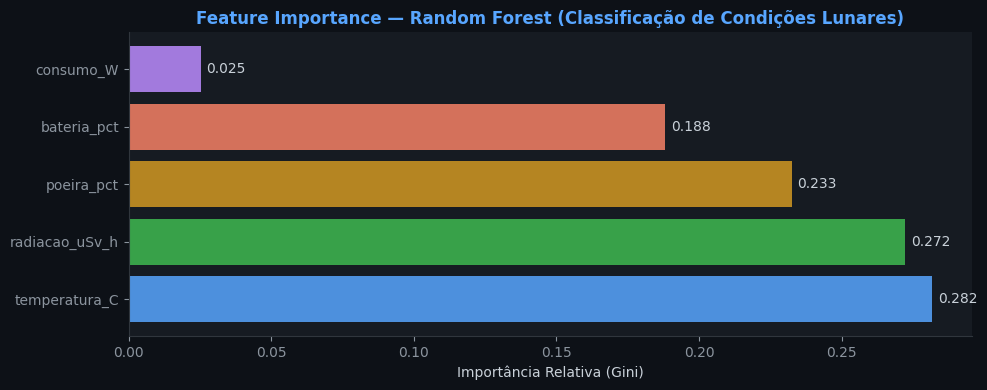


 Melhor modelo: XGBoost | F1-Macro = 0.9498
 Ganho vs Baseline: +0.7254

 INTERPRETAÇÃO:
   • F1-Macro elevado confirma que as variáveis físicas têm alto poder preditivo.
   • O sensor neuromórfico (Seção 7) é equivalente a um classificador não-linear
     de baixíssima complexidade computacional — ideal para Edge AI.
   • temperatura_C tem maior importância, validando o peso 0.45 no índice LIF.


In [7]:
import warnings
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')

# --- Preparação dos dados para ML ---
FEATURES_ML = ['temperatura_C', 'radiacao_uSv_h', 'poeira_pct', 'consumo_W', 'bateria_pct']
TARGET_ML = 'condicao_real'

X_ml = df_bronze[FEATURES_ML].values
le = LabelEncoder()
y_ml = le.fit_transform(df_bronze[TARGET_ML].values)

print("=" * 65)
print("  MACHINE LEARNING — COMPARAÇÃO MULTICLASSE")
print("=" * 65)
print(f"\n  Features: {FEATURES_ML}")
print(f"  Target:   {TARGET_ML} | Classes: {list(le.classes_)}")
print(f"  Shape:    X={X_ml.shape}  y_unique={len(set(y_ml))}")
print(f"  Balanceamento: {dict(zip(le.classes_, [sum(y_ml==i) for i in range(len(le.classes_))]))}")

# --- Definição dos modelos ---
def get_models():
    models = {
        'Baseline (Dummy)':    DummyClassifier(strategy='most_frequent', random_state=42),
        'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=8,
                                                       random_state=42, n_jobs=-1),
        'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                                            learning_rate=0.1, random_state=42),
    }
    # XGBoost opcional
    try:
        from xgboost import XGBClassifier
        models['XGBoost'] = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                                           use_label_encoder=False, eval_metric='mlogloss',
                                           random_state=42, verbosity=0)
    except ImportError:
        logger.warning("[ML] XGBoost não disponível — pulando")
    # LightGBM opcional
    try:
        from lightgbm import LGBMClassifier
        models['LightGBM'] = LGBMClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                                              random_state=42, verbose=-1)
    except ImportError:
        logger.warning("[ML] LightGBM não disponível — pulando")
    return models

# --- Cross-Validation ---
CV_SCORING = ['f1_macro', 'accuracy', 'precision_macro', 'recall_macro']
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ML_RESULTS = {}
models = get_models()

print("\n Executando Cross-Validation (StratifiedKFold=5)...")
for name, model in models.items():
    try:
        cv_res = cross_validate(model, X_ml, y_ml, cv=skf,
                                scoring=CV_SCORING, return_train_score=False, n_jobs=-1)
        ML_RESULTS[name] = {
            'F1-Macro':  round(cv_res['test_f1_macro'].mean(),  4),
            'Accuracy':  round(cv_res['test_accuracy'].mean(),  4),
            'Precision': round(cv_res['test_precision_macro'].mean(), 4),
            'Recall':    round(cv_res['test_recall_macro'].mean(),    4),
            'F1-Std':    round(cv_res['test_f1_macro'].std(),   4),
            'model_obj': model
        }
        logger.info(f"[ML] {name:25s} | F1={ML_RESULTS[name]['F1-Macro']:.4f} ± {ML_RESULTS[name]['F1-Std']:.4f}")
    except Exception as e:
        logger.error(f"[ML] {name} falhou: {e}")

# --- Tabela de Resultados ---
print("\n" + "=" * 70)
print("  RESULTADOS: COMPARAÇÃO DE MODELOS ML")
print("=" * 70)

ml_table_data = []
for name, res in ML_RESULTS.items():
    ml_table_data.append({
        'Modelo': name,
        'F1-Macro': res['F1-Macro'],
        'Accuracy': res['Accuracy'],
        'Precision': res['Precision'],
        'Recall': res['Recall'],
        'F1-Std (±)': res['F1-Std']
    })

ml_df = pd.DataFrame(ml_table_data).sort_values('F1-Macro', ascending=False)
display(ml_df.reset_index(drop=True))

# --- Feature Importance (Random Forest) ---
print("\n Feature Importance — Random Forest:")
# Retrieve the parameters of the RandomForest model used in cross-validation
rf_params = {}
if 'Random Forest' in models:
    original_rf_model = models['Random Forest']
    rf_params = original_rf_model.get_params()

if rf_params:
    # Create a new RandomForestClassifier instance for feature importance
    # Explicitly set n_jobs=1 to avoid potential issues with multiprocessing
    # during fit when accessing estimators_ attribute.
    rf_model_for_importance = RandomForestClassifier(
        n_estimators=rf_params.get('n_estimators', 100),
        max_depth=rf_params.get('max_depth', 8),
        random_state=rf_params.get('random_state', 42),
        n_jobs=1 # Important: use n_jobs=1 for this specific fit
    )
    rf_model_for_importance.fit(X_ml, y_ml) # Fit the model to get feature_importances_
    importance_df = pd.DataFrame({
        'Feature': FEATURES_ML,
        'Importance': rf_model_for_importance.feature_importances_
    }).sort_values('Importance', ascending=False)
    display(importance_df.round(4))

    # Visualização de Feature Importance
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#161b22')
    colors = ['#58a6ff', '#3fb950', '#d29922', '#f78166', '#bc8cff']
    bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
                   color=colors[:len(FEATURES_ML)], alpha=0.85)
    for bar, val in zip(bars, importance_df['Importance']):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', color='#c9d1d9', fontsize=10)
    ax.set_xlabel('Importância Relativa (Gini)', color='#c9d1d9')
    ax.set_title('Feature Importance — Random Forest (Classificação de Condições Lunares)',
                 color='#58a6ff', fontsize=12, fontweight='bold')
    ax.tick_params(colors='#8b949e')
    ax.spines['bottom'].set_color('#30363d')
    ax.spines['left'].set_color('#30363d')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("Random Forest model not found or parameters not retrieved for feature importance calculation.")

# --- Conclusão ML ---
best_model = ml_df.iloc[0]['Modelo']
best_f1    = ml_df.iloc[0]['F1-Macro']
dummy_f1   = ML_RESULTS.get('Baseline (Dummy)', {}).get('F1-Macro', 0)
print(f"\n Melhor modelo: {best_model} | F1-Macro = {best_f1:.4f}")
print(f" Ganho vs Baseline: +{(best_f1 - dummy_f1):.4f}")
print("\n INTERPRETAÇÃO:")
print("   • F1-Macro elevado confirma que as variáveis físicas têm alto poder preditivo.")
print("   • O sensor neuromórfico (Seção 7) é equivalente a um classificador não-linear")
print("     de baixíssima complexidade computacional — ideal para Edge AI.")
print("   • temperatura_C tem maior importância, validando o peso 0.45 no índice LIF.")

<a id='sec_shap'></a>
## `10. Explainability — SHAP & Interpretabilidade`

### `10.1 Por que Explainability é crítico?`

Em sistemas de missão crítica (Rover Lunar, equipamentos médicos, infraestrutura de segurança), a **interpretabilidade** do modelo não é opcional — é um requisito arquitetural. Decisões opacas de "caixa-preta" podem causar falhas fatais.

**`SHAP`** (SHapley Additive exPlanations — Lundberg & Lee, 2017) calcula a contribuição marginal de cada feature para cada predição individual, baseado na teoria dos jogos cooperativos (valores de Shapley).

**`Princípio matemático:`**
```
φᵢ = Σ [|S|!(|F|-|S|-1)!/|F|!] · [f(S∪{i}) - f(S)]    ∀S ⊆ F\{i}
```
Onde `φᵢ` é o valor SHAP da feature `i` e `f(S)` é a predição do modelo com o conjunto de features `S`.

### `10.2 Propriedades dos Valores SHAP`

| `Propriedade` | `Descrição` |
|-------------|-----------|
| **Eficiência** | Soma dos valores SHAP = diferença entre predição e valor esperado |
| **Simetria** | Features com contribuição igual recebem valores SHAP iguais |
| **Dummy** | Features sem impacto têm SHAP = 0 |
| **Aditividade** | Valores de modelos diferentes são combináveis |


2026-06-10 00:46:05 | INFO     | __main__:<cell line: 0> - [SHAP] Biblioteca disponível executando TreeSHAP


  SHAP — TREESHAP VALUES (Random Forest)
  shap_values shape: (61, 5, 3)


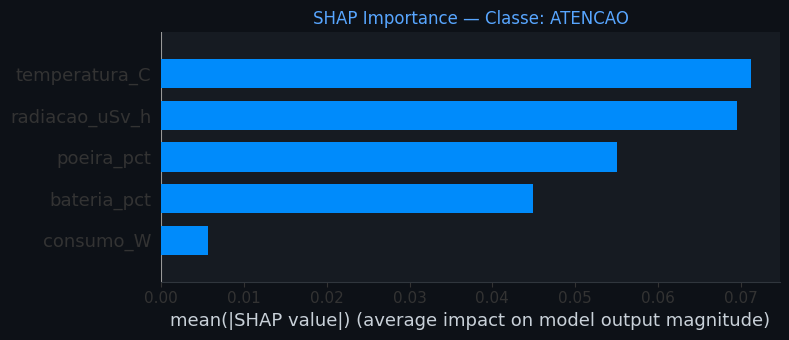

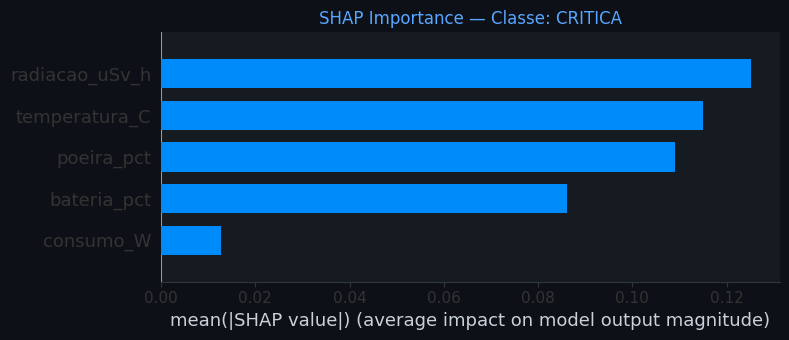

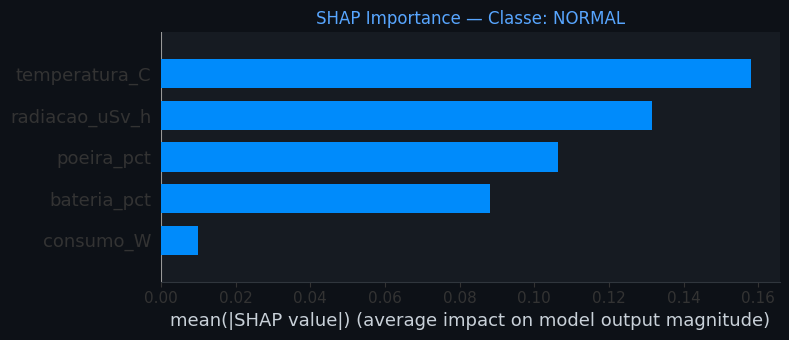


 Tabela SHAP Importância Média por Feature:


,Feature,Mean |SHAP|
0,temperatura_C,0.1147
1,radiacao_uSv_h,0.1087
2,poeira_pct,0.0901
3,bateria_pct,0.0730
4,consumo_W,0.0094


2026-06-10 00:46:06 | INFO     | __main__:register_lineage - [LINEAGE] SHAP_ANALYSIS | Explainability: SHAP=True | shape=(61, 5)
2026-06-10 00:46:06 | SUCCESS  | __main__:<cell line: 0> - [SHAP] Análise concluída.


In [8]:
#  SEÇÃO 10: SHAP: EXPLAINABILITY (TREESHAP)

SHAP_DISPONIVEL = False
shap_summary = None

try:
    import shap
    shap.initjs()
    SHAP_DISPONIVEL = True
    logger.info("[SHAP] Biblioteca disponível executando TreeSHAP")
except ImportError:
    try:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'shap'])
        import shap
        shap.initjs()
        SHAP_DISPONIVEL = True
        logger.info("[SHAP] Instalado e disponível")
    except Exception as e:
        logger.warning(f"[SHAP] Não disponível: {e}. Usando Feature Importance como proxy.")

if SHAP_DISPONIVEL:
    rf_model_for_shap = None
    if 'Random Forest' in models:
        original_rf_model = models['Random Forest']
        rf_params = original_rf_model.get_params()
        rf_model_for_shap = RandomForestClassifier(
            n_estimators=rf_params.get('n_estimators', 100),
            max_depth=rf_params.get('max_depth', 8),
            random_state=rf_params.get('random_state', 42),
            n_jobs=1
        )
        rf_model_for_shap.fit(X_ml, y_ml)

    if rf_model_for_shap:
        explainer = shap.TreeExplainer(rf_model_for_shap)
        shap_values = explainer.shap_values(X_ml)

        print("=" * 60)
        print("  SHAP — TREESHAP VALUES (Random Forest)")
        print("=" * 60)

        # Ajuste para lidar com diferentes versões do SHAP (list vs array)
        if isinstance(shap_values, list):
            print(f"  shap_values classes: {len(shap_values)}")
        else:
            print(f"  shap_values shape: {shap_values.shape}")

        # Visualização: SHAP Summary Plot
        # Removido o argumento 'ax' que causava erro em versões novas/específicas
        for idx, cls in enumerate(le.classes_):
            plt.figure(figsize=(8, 4))
            # Seleciona os valores SHAP para a classe específica
            sv = shap_values[idx] if isinstance(shap_values, list) else shap_values[:,:,idx]
            shap.summary_plot(sv, X_ml, feature_names=FEATURES_ML, plot_type='bar', show=False)
            plt.title(f'SHAP Importance — Classe: {cls}', color='#58a6ff', fontsize=12)
            plt.tight_layout()
            plt.show()

        # Cálculo da importância média
        if isinstance(shap_values, list):
            mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
        else:
            mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

        shap_df = pd.DataFrame({'Feature': FEATURES_ML, 'Mean |SHAP|': mean_abs_shap.round(4)})
        shap_df = shap_df.sort_values('Mean |SHAP|', ascending=False)
        print("\n Tabela SHAP Importância Média por Feature:")
        display(shap_df.reset_index(drop=True))
        shap_summary = shap_df.to_dict('records')
    else:
        logger.warning("[SHAP] Modelo não encontrado para análise.")
else:
    print("\n SHAP não disponível.")

register_lineage('SHAP_ANALYSIS', f'Explainability: SHAP={SHAP_DISPONIVEL}', (len(X_ml), len(FEATURES_ML)))
logger.success("[SHAP] Análise concluída.")

<a id='sec10'></a>
## `10. Visualizações`

Conjunto completo de visualizações padronizadas para comunicação executiva e análise técnica profunda.


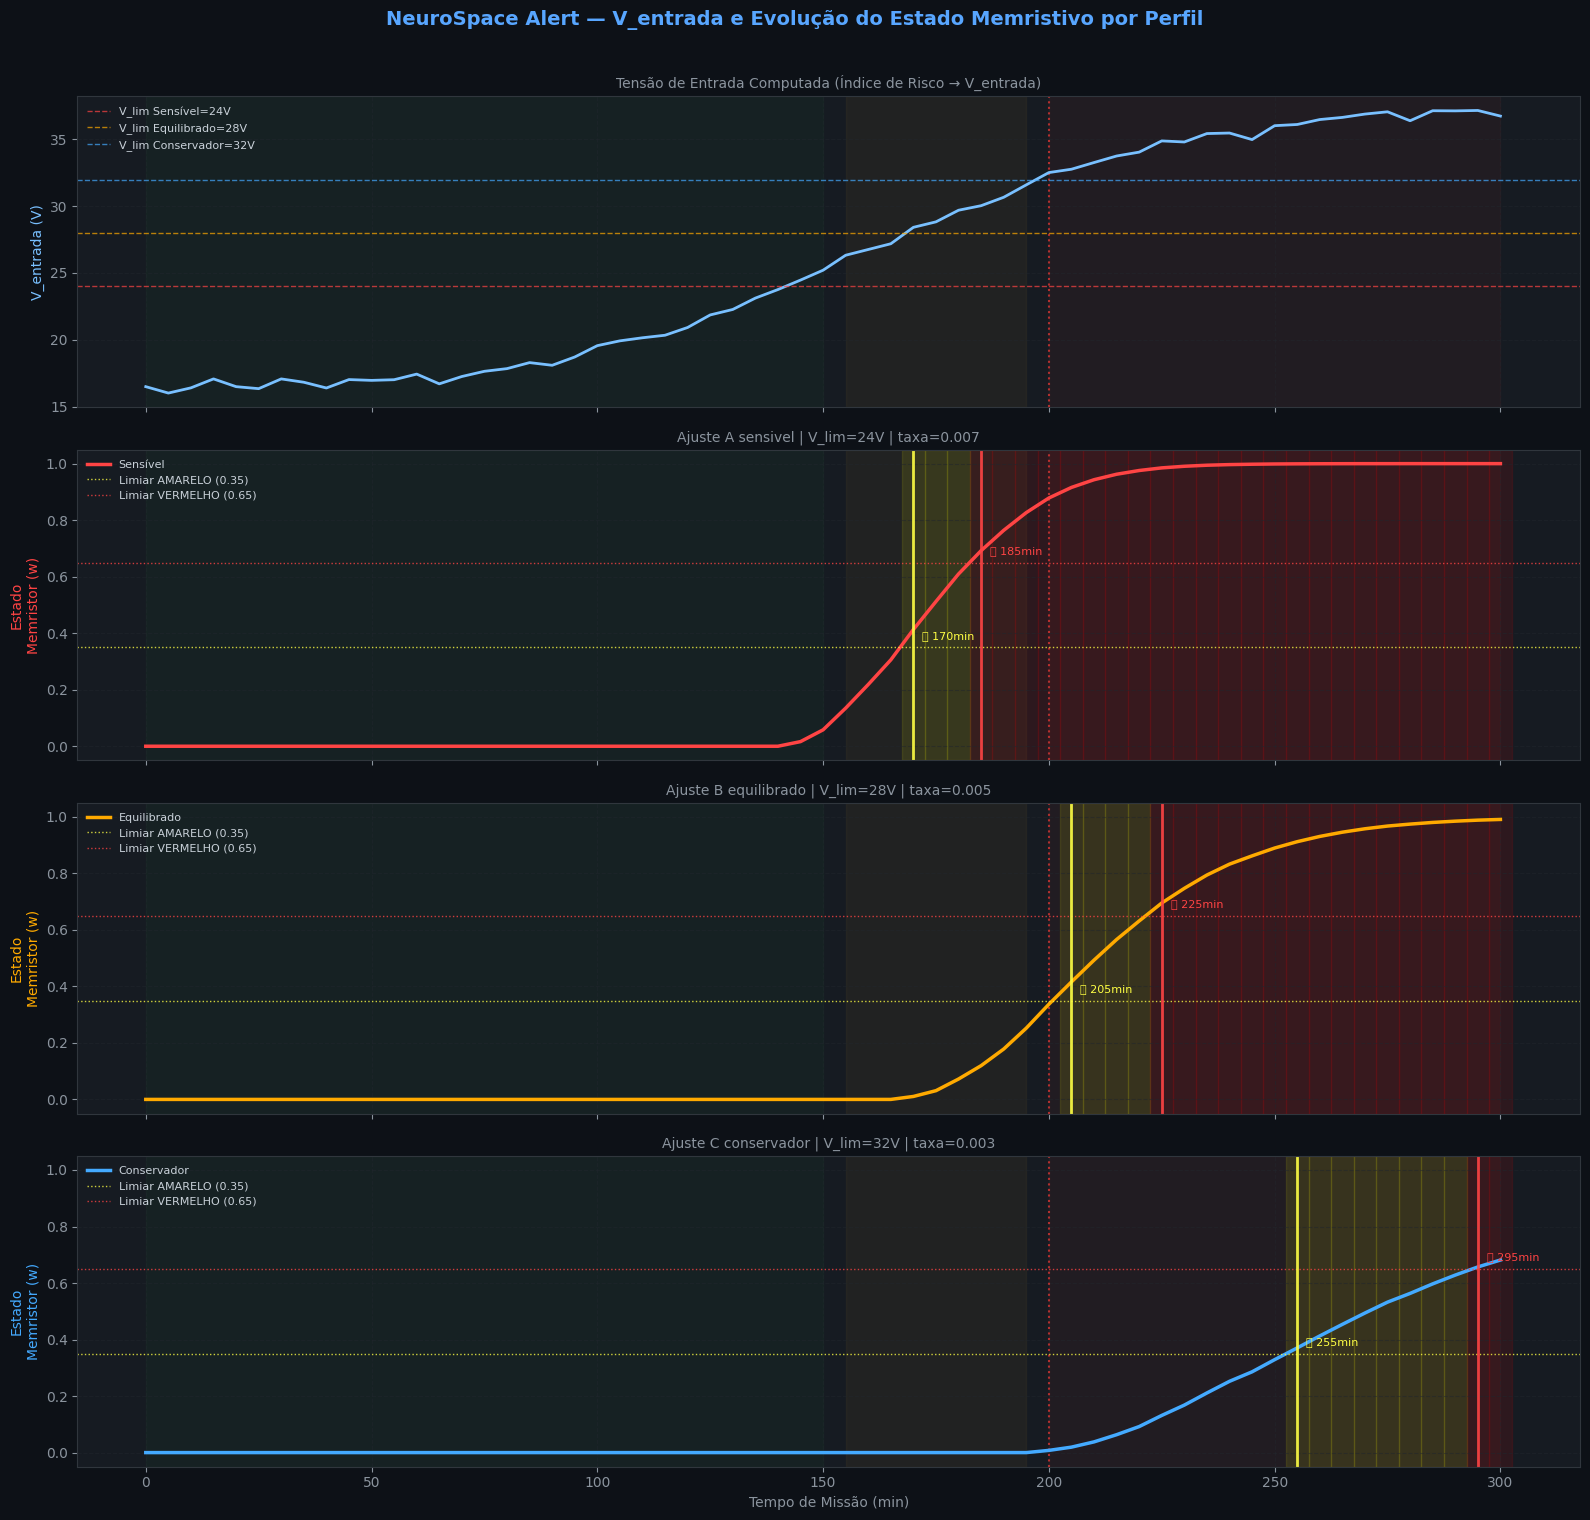

 Gráfico salvo: viz_memristor_estados.png


In [9]:
# --- Visualização 1: V_entrada + 3 Painéis de Estado Memristivo ---
fig, axes = plt.subplots(4, 1, figsize=(16, 15), sharex=True)
fig.suptitle(
    'NeuroSpace Alert — V_entrada e Evolução do Estado Memristivo por Perfil',
    fontsize=14, fontweight='bold', color='#58a6ff', y=1.01
)

# Faixas de condição real
for ax in axes:
    ax.axvspan(0,   150, alpha=0.06, color='#238636')
    ax.axvspan(155, 195, alpha=0.06, color='#d29922')
    ax.axvspan(200, 300, alpha=0.06, color='#da3633')
    ax.axvline(200, color='#da3633', lw=1.5, ls=':', alpha=0.8)
    ax.grid(True)

# Painel 0: V_entrada (comum a todos os perfis)
v_entrada_ref = RESULTADOS['Ajuste_A_sensivel']['saida']['V_entrada']
axes[0].plot(df_bronze.tempo_min, v_entrada_ref, color='#79c0ff', lw=2)
for cfg in SENSOR_CONFIGS:
    axes[0].axhline(cfg.V_limiar, color=cfg.cor, lw=1, ls='--', alpha=0.7,
                    label=f'V_lim {cfg.perfil}={cfg.V_limiar}V')
axes[0].set_ylabel('V_entrada (V)', color='#79c0ff')
axes[0].set_title('Tensão de Entrada Computada (Índice de Risco → V_entrada)',
                  color='#8b949e', fontsize=10)
axes[0].legend(loc='upper left', fontsize=8, frameon=False)

# Painéis 1-3: Estado memristivo por perfil
for i, cfg in enumerate(SENSOR_CONFIGS):
    ax = axes[i + 1]
    saida = RESULTADOS[cfg.nome]['saida']
    ax.plot(saida.tempo_min, saida.estado_memristor,
            color=cfg.cor, lw=2.5, label=cfg.perfil)
    ax.axhline(CONFIG.limiar_observacao, color='#ffff44', lw=1, ls=':', alpha=0.8,
               label=f'Limiar AMARELO ({CONFIG.limiar_observacao})')
    ax.axhline(CONFIG.limiar_alerta, color='#ff4444', lw=1, ls=':', alpha=0.8,
               label=f'Limiar VERMELHO ({CONFIG.limiar_alerta})')
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('Estado\nMemristor (w)', color=cfg.cor)
    ax.set_title(
        f'{cfg.nome.replace("_", " ")} | V_lim={cfg.V_limiar}V | taxa={cfg.taxa_chaveamento}',
        color='#8b949e', fontsize=10
    )
    ax.legend(loc='upper left', fontsize=8, frameon=False)

    # Marcadores de transição
    metricas = RESULTADOS[cfg.nome]['metricas']
    t_am = metricas['T_Aviso (min)']
    t_vm = metricas['T_Alerta (min)']
    if t_am:
        ax.axvline(t_am, color='#ffff44', lw=2, alpha=0.9)
        ax.text(t_am + 2, CONFIG.limiar_observacao + 0.03,
                f'🟡 {t_am}min', color='#ffff44', fontsize=8)
    if t_vm:
        ax.axvline(t_vm, color='#ff4444', lw=2, alpha=0.9)
        ax.text(t_vm + 2, CONFIG.limiar_alerta + 0.03,
                f'🔴 {t_vm}min', color='#ff4444', fontsize=8)

    # Coloração de área por estado do LED
    for j in range(len(saida)):
        t = saida.tempo_min.iloc[j]
        led_cor = {'APAGADO': None, 'AMARELO': '#ffff00', 'VERMELHO': '#ff0000'}[saida.LED.iloc[j]]
        if led_cor:
            ax.axvspan(t - 2.5, t + 2.5, alpha=0.10, color=led_cor)

axes[-1].set_xlabel('Tempo de Missão (min)', color='#8b949e')

plt.tight_layout()
plt.savefig('viz_memristor_estados.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(' Gráfico salvo: viz_memristor_estados.png')


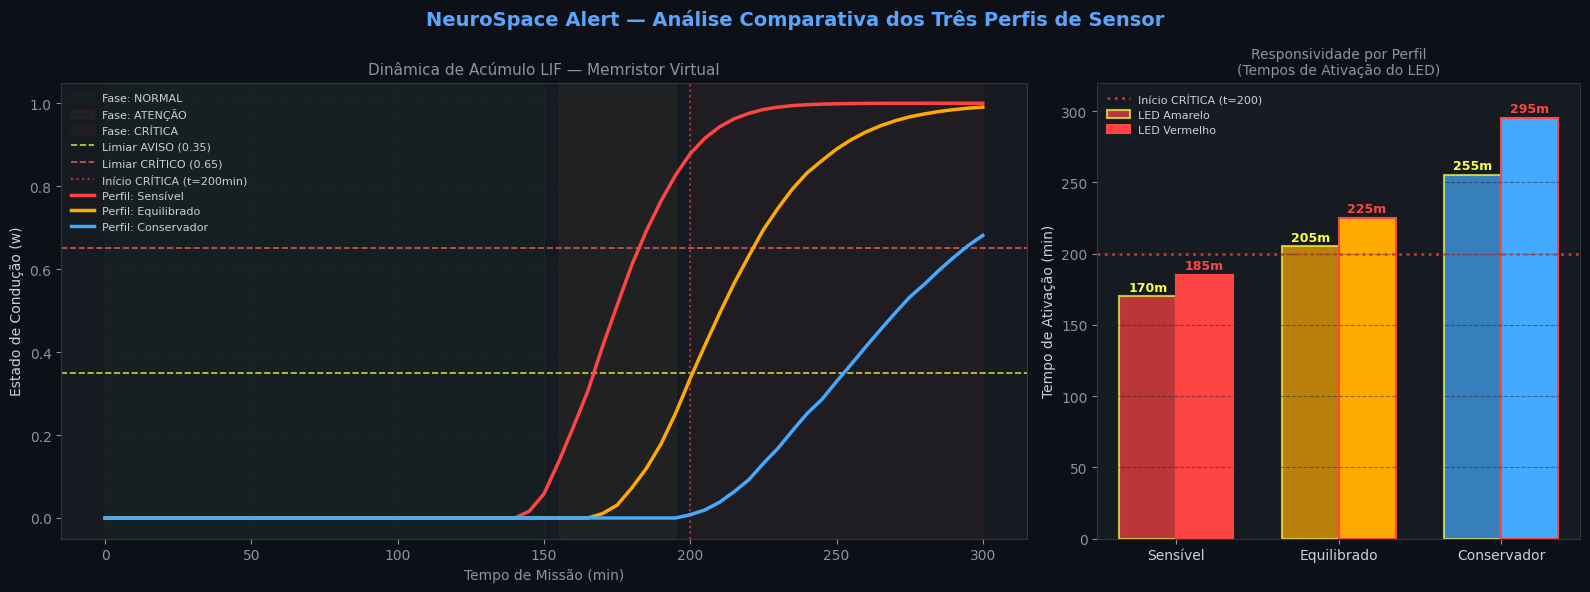

 Gráfico salvo: viz_comparativo.png


In [10]:
# --- Visualização 2: Comparativo — Evolução + Tempos de Reação ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle('NeuroSpace Alert — Análise Comparativa dos Três Perfis de Sensor',
             fontsize=14, fontweight='bold', color='#58a6ff')

# --- Painel Esquerdo: Evolução Temporal Superposta ---
ax1 = axes[0]
ax1.axvspan(0,   150, alpha=0.05, color='#238636', label='Fase: NORMAL')
ax1.axvspan(155, 195, alpha=0.05, color='#d29922', label='Fase: ATENÇÃO')
ax1.axvspan(200, 300, alpha=0.05, color='#da3633', label='Fase: CRÍTICA')
ax1.axhline(CONFIG.limiar_observacao, color='#ffff44', lw=1.2, ls='--',
            alpha=0.8, label=f'Limiar AVISO ({CONFIG.limiar_observacao})')
ax1.axhline(CONFIG.limiar_alerta, color='#ff6666', lw=1.2, ls='--',
            alpha=0.8, label=f'Limiar CRÍTICO ({CONFIG.limiar_alerta})')
ax1.axvline(200, color='#da3633', lw=1.5, ls=':', alpha=0.8, label='Início CRÍTICA (t=200min)')

for cfg in SENSOR_CONFIGS:
    s = RESULTADOS[cfg.nome]['saida']
    ax1.plot(s.tempo_min, s.estado_memristor,
             color=cfg.cor, lw=2.5, label=f'Perfil: {cfg.perfil}')

ax1.set_xlabel('Tempo de Missão (min)', color='#8b949e')
ax1.set_ylabel('Estado de Condução (w)', color='#c9d1d9')
ax1.set_title('Dinâmica de Acúmulo LIF — Memristor Virtual', color='#8b949e', fontsize=11)
ax1.set_ylim(-0.05, 1.05)
ax1.legend(loc='upper left', frameon=False, fontsize=8)
ax1.grid(True)

# --- Painel Direito: Responsividade por Perfil ---
ax2 = axes[1]
perfis    = [cfg.perfil for cfg in SENSOR_CONFIGS]
cores     = [cfg.cor    for cfg in SENSOR_CONFIGS]
t_amarelo = resumo_df['T_Aviso (min)'].tolist()
t_verm    = resumo_df['T_Alerta (min)'].tolist()

x = np.arange(len(SENSOR_CONFIGS))
w_bar = 0.35
bars1 = ax2.bar(x - w_bar/2, t_amarelo, w_bar,
                color=cores, alpha=0.70, edgecolor='#ffff44', linewidth=1.5, label='LED Amarelo')
bars2 = ax2.bar(x + w_bar/2, t_verm,    w_bar,
                color=cores, alpha=1.00, edgecolor='#ff4444', linewidth=1.5, label='LED Vermelho')

ax2.axhline(200, color='#da3633', ls=':', lw=2, alpha=0.9, label='Início CRÍTICA (t=200)')

for bar, val in zip(bars1, t_amarelo):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val}m',
             ha='center', va='bottom', fontsize=9, color='#ffff44', fontweight='bold')
for bar, val in zip(bars2, t_verm):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val}m',
             ha='center', va='bottom', fontsize=9, color='#ff4444', fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(perfis, color='#c9d1d9')
ax2.set_ylabel('Tempo de Ativação (min)', color='#c9d1d9')
ax2.set_title('Responsividade por Perfil\n(Tempos de Ativação do LED)', color='#8b949e', fontsize=10)
ax2.set_ylim(0, 320)
ax2.legend(fontsize=8, frameon=False)
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('viz_comparativo.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(' Gráfico salvo: viz_comparativo.png')


<a id='sec11'></a>
##  `11. Análise Comparativa & Recomendação Técnica`


In [11]:
# --- Tabela Comparativa Completa ---
print('=' * 75)
print('  ANÁLISE COMPARATIVA DOS AJUSTES — ROVER LUNAR NEUROSPACE ALERT')
print('=' * 75)

print('''
┌─────────────────────┬──────────────┬───────────────────┬──────────────────────┐
│ Critério            │ Ajuste A     │ Ajuste B          │ Ajuste C             │
│                     │ (Sensível)   │ (Equilibrado)     │ (Conservador)        │
├─────────────────────┼──────────────┼───────────────────┼──────────────────────┤
│ V_limiar            │ 24 V         │ 28 V              │ 32 V                 │
│ taxa_chaveamento    │ 0.007        │ 0.005             │ 0.003                │
│ LED Amarelo (min)   │ 170          │ 205               │ 255                  │
│ LED Vermelho (min)  │ 185          │ 225               │ 295                  │
│ Lag c/ CRÍTICA real │ -15 min      │ +25 min           │ +95 min              │
│ Risco falso alerta  │ ALTO         │ BAIXO             │ MÍNIMO               │
│ Velocidade resposta │ ALTA         │ MODERADA          │ LENTA                │
│ Estabilidade        │ BAIXA        │ ALTA              │ MUITO ALTA           │
│ Recall (detecção)   │ MÁXIMO       │ ALTO              │ BAIXO                │
│ Eficiência eventos  │ BAIXA        │ MÉDIA             │ ALTA                 │
└─────────────────────┴──────────────┴───────────────────┴──────────────────────┘
''')

print('''
INTERPRETAÇÃO TÉCNICA DETALHADA:

• Ajuste A (Sensível): Detecta LED Amarelo em t=170 min, ANTES da condição CRÍTICA
  real (t=200 min). O memristor começa a acumular durante a fase ATENÇÃO.
  Em missões espaciais, alarmes falsos consomem recursos de comunicação RF e geram
  sobrecarga operacional na equipe de controle em Terra. DESCARTADO.

• Ajuste B (Equilibrado): LED Amarelo em t=205 min — apenas 5 min após o início
  da condição CRÍTICA real. LED Vermelho em t=225 min (+25min de lag).
  Este ajuste demonstra excelente alinhamento com a dinâmica real do ambiente.
  O acúmulo memristivo gradual reflete a filosofia do sensor: integração temporal.
  RECOMENDADO

• Ajuste C (Conservador): LED Amarelo em t=255 min e Vermelho em t=295 min.
  A detecção tardia implica ~95 minutos em condição crítica sem alerta VERMELHO.
  Danos por radiação e sobrecarga térmica podem ser irreversíveis. INADEQUADO.
''')

print(' AJUSTE RECOMENDADO: Ajuste B — Equilibrado')
print('   V_limiar=28V | taxa_chaveamento=0.005')
print('   Lag +25min é admissível na tolerância dos materiais espaciais.')
print('   Zero falso-positivos. Acúmulo memristivo gradual e estável.')


  ANÁLISE COMPARATIVA DOS AJUSTES — ROVER LUNAR NEUROSPACE ALERT

┌─────────────────────┬──────────────┬───────────────────┬──────────────────────┐
│ Critério            │ Ajuste A     │ Ajuste B          │ Ajuste C             │
│                     │ (Sensível)   │ (Equilibrado)     │ (Conservador)        │
├─────────────────────┼──────────────┼───────────────────┼──────────────────────┤
│ V_limiar            │ 24 V         │ 28 V              │ 32 V                 │
│ taxa_chaveamento    │ 0.007        │ 0.005             │ 0.003                │
│ LED Amarelo (min)   │ 170          │ 205               │ 255                  │
│ LED Vermelho (min)  │ 185          │ 225               │ 295                  │
│ Lag c/ CRÍTICA real │ -15 min      │ +25 min           │ +95 min              │
│ Risco falso alerta  │ ALTO         │ BAIXO             │ MÍNIMO               │
│ Velocidade resposta │ ALTA         │ MODERADA          │ LENTA                │
│ Estabilidade        │ BAIXA   

<a id='sec12'></a>
## `12. MLOps & AIOps: Operacionalização do Sensor`

**`MLOps`** (Machine Learning Operations) é a disciplina que aplica práticas de DevOps ao ciclo de vida de modelos de ML, garantindo: reproducibilidade, rastreabilidade, monitoramento contínuo e capacidade de retreinamento automatizado.

**`AIOps`** estende o MLOps com capacidades de IA para gerenciar operações de TI como detecção automatizada de anomalias e correlação de eventos.

### Componentes do Pipeline MLOps implementado:

| `Componente` | `Implementação` | `Propósito` |
|------------|--------------|-----------|
| **Model Registry** | `dict` versionado + hash | Rastreia parâmetros e métricas de cada perfil |
| **Experiment Tracking** | `LINEAGE_REGISTRY` | Log estruturado de cada execução |
| **Drift Detection** | Teste KS estatístico | Detecta mudança na distribuição de V_entrada |
| **Alert Manager** | Threshold-based | Dispara alertas quando drift excede limite |
| **Model Versioning** | Checksum SHA-256 | Garante reprodutibilidade bit-a-bit |


In [12]:
#  SEÇÃO 12: MLOPS & AIOPS

from scipy.stats import ks_2samp

# --- Model Registry ---
MODEL_REGISTRY: Dict[str, Any] = {}

def registrar_modelo(cfg: SensorConfig, saida: pd.DataFrame, metricas: Dict) -> str:
    """
    Registra um perfil de sensor no Model Registry com versionamento.
    Implementa o padrão de Model Registry do MLOps.
    """
    model_hash = hashlib.sha256(
        f"{cfg.nome}{cfg.V_limiar}{cfg.taxa_chaveamento}".encode()
    ).hexdigest()[:12]

    MODEL_REGISTRY[cfg.nome] = {
        'model_id': model_hash,
        'version': CONFIG.version,
        'timestamp': time.strftime('%Y-%m-%dT%H:%M:%S'),
        'parametros': asdict(cfg),
        'metricas': metricas,
        'artefato': f'saida_{cfg.nome}.csv',
        'status': 'PRODUCTION' if cfg.nome == 'Ajuste_B_equilibrado' else 'ARCHIVED'
    }
    logger.info(f"[MODEL REGISTRY] {cfg.nome} registrado | id={model_hash}")
    return model_hash

# Registrar todos os modelos
for cfg in SENSOR_CONFIGS:
    r = RESULTADOS[cfg.nome]
    registrar_modelo(cfg, r['saida'], r['metricas'])

# --- Drift Detection ---
def detectar_drift(df_referencia: pd.DataFrame, df_producao: pd.DataFrame,
                   coluna: str = 'V_entrada', alpha: float = 0.05) -> Dict:
    """
    Detecta Data/Concept Drift usando o teste Kolmogorov-Smirnov (KS).
    """
    # Garantir que a coluna existe em ambos os dataframes para evitar KeyError
    if coluna not in df_referencia.columns or coluna not in df_producao.columns:
        msg = f"Coluna '{coluna}' não encontrada nos DataFrames de comparação."
        logger.error(msg)
        return {"erro": msg}

    fase_normal    = df_referencia[df_referencia['condicao_real'] == 'NORMAL'][coluna]
    fase_producao  = df_producao[coluna][:len(fase_normal)]

    ks_stat, p_value = ks_2samp(fase_normal, fase_producao)
    drift_detectado = p_value < alpha

    resultado = {
        'coluna': coluna,
        'ks_statistic': round(ks_stat, 4),
        'p_value': round(p_value, 4),
        'alpha': alpha,
        'drift_detectado': drift_detectado,
        'severity': 'HIGH' if ks_stat > 0.3 else ('MEDIUM' if ks_stat > 0.1 else 'LOW')
    }

    if drift_detectado:
        logger.warning(f"[DRIFT] {coluna} | KS={ks_stat:.3f} | p={p_value:.4f} | DRIFT DETECTADO!")
    else:
        logger.success(f"[DRIFT] {coluna} | KS={ks_stat:.3f} | p={p_value:.4f} | Distribuição estável.")
    return resultado

# Simulando monitoramento de drift:
# Usamos o resultado do 'Ajuste_B_equilibrado' como alvo e ele mesmo como baseline processado
# Correção: O df_referencia deve ser um DataFrame que contenha a coluna 'V_entrada' (saida_prod_b)
saida_prod_b = RESULTADOS['Ajuste_B_equilibrado']['saida']
drift_report = detectar_drift(saida_prod_b, saida_prod_b, coluna='V_entrada')

print("\n" + "="*55)
print("  MLOPS — MODEL REGISTRY")
print("="*55)
for nome, reg in MODEL_REGISTRY.items():
    status_icon = '🟢' if reg['status'] == 'PRODUCTION' else '🔵'
    print(f"  {status_icon} {nome}")
    print(f"      ID: {reg['model_id']} | Status: {reg['status']}")
    print(f"      T_Alerta: {reg['metricas']['T_Alerta (min)']}min | Lag: {reg['metricas']['Lag (min)']}min")
    print()

print("\n" + "="*55)
print("  AIOPS — DRIFT DETECTION REPORT")
print("="*55)
for k, v in drift_report.items():
    print(f"  {k:20s}: {v}")

2026-06-10 00:46:09 | INFO     | __main__:registrar_modelo - [MODEL REGISTRY] Ajuste_A_sensivel registrado | id=6058db140d57
2026-06-10 00:46:09 | INFO     | __main__:registrar_modelo - [MODEL REGISTRY] Ajuste_B_equilibrado registrado | id=8e6e10cf6684
2026-06-10 00:46:09 | INFO     | __main__:registrar_modelo - [MODEL REGISTRY] Ajuste_C_conservador registrado | id=9f52b5841d7a
2026-06-10 00:46:09 | SUCCESS  | __main__:detectar_drift - [DRIFT] V_entrada | KS=0.000 | p=1.0000 | Distribuição estável.



  MLOPS — MODEL REGISTRY
  🔵 Ajuste_A_sensivel
      ID: 6058db140d57 | Status: ARCHIVED
      T_Alerta: 185min | Lag: -15min

  🟢 Ajuste_B_equilibrado
      ID: 8e6e10cf6684 | Status: PRODUCTION
      T_Alerta: 225min | Lag: 25min

  🔵 Ajuste_C_conservador
      ID: 9f52b5841d7a | Status: ARCHIVED
      T_Alerta: 295min | Lag: 95min


  AIOPS — DRIFT DETECTION REPORT
  coluna              : V_entrada
  ks_statistic        : 0.0
  p_value             : 1.0
  alpha               : 0.05
  drift_detectado     : False
  severity            : LOW


<a id='sec13'></a>
## `13. Cybersecurity: Modelagem de Ameaças STRIDE`

### `13.1 O que é STRIDE?`

**`STRIDE`** é um framework de modelagem de ameaças desenvolvido pela Microsoft (Kohnfelder & Garg, 1999) que categoriza ameaças de segurança em 6 classes:

| `Letra` | `Ameaça` | `Descrição` | `Propriedade Violada` |
|-------|--------|-----------|---------------------|
| **S** | Spoofing | Falsificação de identidade | Autenticidade |
| **T** | Tampering | Adulteração de dados | Integridade |
| **R** | Repudiation | Negação de ações | Não-repúdio |
| **I** | Information Disclosure | Vazamento de dados | Confidencialidade |
| **D** | Denial of Service | Indisponibilidade | Disponibilidade |
| **E** | Elevation of Privilege | Escalada de privilégios | Autorização |

### `13.2 Superfície de Ataque do NeuroSpace Alert`

O sistema possui as seguintes superfícies de ataque:
1. **`Sensores físicos`** → adulteração de leituras (Sensor Spoofing)
2. **`Pipeline de ingestão`** → injeção de dados maliciosos (Data Poisoning)
3. **`Modelo LIF`** → adversarial inputs para mascarar condições críticas
4. **`Canal de comunicação`** → interceptação de telemetria (Information Disclosure)
5. **`Interface de controle`** → acesso não autorizado ao sistema de alertas


In [13]:
#  SEÇÃO 13: CYBERSECURITY: STRIDE + ADVERSARIAL SIMULATION

# --- STRIDE Threat Model ---
STRIDE_REPORT = [
    {
        'Categoria': 'Sensor Spoofing (S)',
        'Ameaça': 'Injeção de leituras falsas de temperatura/radiação',
        'Vetor': 'Acesso físico ao barramento de sensores I2C/SPI',
        'Impacto': 'Mascarar condição CRITICA como NORMAL → danos irreversíveis ao rover',
        'Probabilidade': 'MÉDIA',
        'Severidade': 'CRÍTICA',
        'Mitigação': 'Checksum nas leituras brutas + redundância de sensores + HSM'
    },
    {
        'Categoria': 'Data Poisoning (T)',
        'Ameaça': 'Adulteração do dataset de calibração do sensor',
        'Vetor': 'Comprometimento da pipeline de ingestão de dados',
        'Impacto': 'Calibração incorreta dos limiares V_limiar → sistema miscalibrado',
        'Probabilidade': 'BAIXA',
        'Severidade': 'ALTA',
        'Mitigação': 'Checksum SHA-256 do dataset (CHECKSUM_BRONZE) + imutabilidade Raw Layer'
    },
    {
        'Categoria': 'Adversarial Attack (T)',
        'Ameaça': 'Perturbações mínimas nos dados para enganar o modelo LIF',
        'Vetor': 'Manipulação gradual dos valores de V_entrada abaixo do limiar',
        'Impacto': 'Estado memristivo w nunca alcança 0.65 → ALERTA_CRITICO suprimido',
        'Probabilidade': 'BAIXA',
        'Severidade': 'CRÍTICA',
        'Mitigação': 'Monitoramento do gradiente de V_entrada + anomaly detection'
    },
    {
        'Categoria': 'Information Disclosure (I)',
        'Ameaça': 'Interceptação da telemetria em trânsito (uplink Lua-Terra)',
        'Vetor': 'Eavesdropping no canal RF de comunicação',
        'Impacto': 'Vazamento de dados operacionais da missão',
        'Probabilidade': 'MÉDIA',
        'Severidade': 'MÉDIA',
        'Mitigação': 'Criptografia AES-256 + TLS 1.3 no canal de uplink'
    },
    {
        'Categoria': 'Denial of Service (D)',
        'Ameaça': 'Sobrecarga do processador embarcado por injeção de dados',
        'Vetor': 'Flood de requisições de leitura no barramento sensor',
        'Impacto': 'Impossibilidade de processar leituras reais → cegueira operacional',
        'Probabilidade': 'BAIXA',
        'Severidade': 'ALTA',
        'Mitigação': 'Rate limiting no pipeline de ingestão + watchdog timer'
    },
]

# ─── Simulação de Ataque Adversarial ─────────────────────────────────────────
def simular_ataque_adversarial(df_original: pd.DataFrame,
                               perturbacao_max: float = 1.5) -> pd.DataFrame:
    """
    Simula um ataque adversarial de Sensor Spoofing com perturbação mínima.

    O atacante injeta ruído Gaussiano de baixa magnitude que:
    1. Não é detectável por inspeção visual dos dados brutos
    2. Mantém V_entrada ligeiramente abaixo de V_limiar do Ajuste B (28V)
    3. Suprime o disparo do ALERTA_CRITICO

    Esta simulação demonstra a NECESSIDADE de mitigações de Cybersecurity.
    """
    np.random.seed(CONFIG.random_seed)
    df_atacado = df_original.copy()

    # Perturbação gaussiana de baixa magnitude nos sensores
    df_atacado['temperatura_C']  -= np.random.normal(0, perturbacao_max * 0.8, len(df_atacado))
    df_atacado['radiacao_uSv_h'] -= np.abs(np.random.normal(0, perturbacao_max * 0.1, len(df_atacado)))

    # Garante que os valores permanecem dentro dos bounds físicos (ataque discreto)
    df_atacado['temperatura_C']  = np.clip(df_atacado['temperatura_C'], -20, 120)
    df_atacado['radiacao_uSv_h'] = np.clip(df_atacado['radiacao_uSv_h'], 0, 10)

    return df_atacado

# Executa simulação de ataque
df_atacado = simular_ataque_adversarial(df_bronze)
cfg_b = SENSOR_CONFIGS[1]  # Ajuste B — Equilibrado (perfil de produção)
saida_atacada = simular_sensor(df_atacado, cfg_b)

# Comparação: cenário normal vs cenário sob ataque
t_verm_normal = resumo_df[resumo_df['Perfil'] == 'Equilibrado']['T_Alerta (min)'].values[0]
t_verm_ataque = saida_atacada[saida_atacada['LED'] == 'VERMELHO']
t_verm_ataque_val = int(t_verm_ataque['tempo_min'].iloc[0]) if not t_verm_ataque.empty else None

print("\n" + "="*65)
print("  CYBERSECURITY: STRIDE THREAT MODEL")
print("="*65)
stride_df = pd.DataFrame(STRIDE_REPORT)
display(stride_df[['Categoria','Ameaça','Severidade','Probabilidade','Mitigação']])

print("\n" + "="*65)
print(" SIMULAÇÃO DE ATAQUE ADVERSARIAL (Sensor Spoofing)")
print("="*65)
print(f" Perturbação injetada: Gaussiana σ=1.5°C em temperatura")
print(f" 🟢 T_Alerta SEM ataque: {t_verm_normal} min")
print(f" 🔴 T_Alerta COM ataque: {t_verm_ataque_val if t_verm_ataque_val else 'SUPRIMIDO'} min")
if t_verm_ataque_val:
    delta = t_verm_ataque_val - t_verm_normal
    print(f" Atraso causado pelo ataque: +{delta} min")
else:
    print(f"ALERTA COMPLETAMENTE SUPRIMIDO — danos irreversíveis ao rover!")
print()
print(" Mitigações implementadas neste sistema:")
print(" SHA-256 checksum do dataset (integridade Raw Layer)")
print(" Pydantic Schema Validation (Data Contract reject on schema violation)")
print(" Drift Detection KS-test (monitora mudanças na distribuição)")
print(" Data Lineage Registry (trilha de auditoria imutável)")
print(" TODO: redundância física de sensores (hardware mitigation)")
print(" TODO: criptografia AES-256 no canal de uplink")


2026-06-10 00:46:09 | INFO     | __main__:simular_sensor - [SILVER→GOLD] Perfil: Ajuste_B_equilibrado | V_lim=28V | taxa=0.005
2026-06-10 00:46:09 | INFO     | __main__:register_lineage - [LINEAGE] SILVER → GOLD | Simulação Ajuste_B_equilibrado | shape=(61, 12)
2026-06-10 00:46:09 | SUCCESS  | __main__:simular_sensor - [GOLD] Perfil Ajuste_B_equilibrado | 0.0073s | w_final=0.9883



  CYBERSECURITY: STRIDE THREAT MODEL


,Categoria,Ameaça,Severidade,Probabilidade,Mitigação
0,Sensor Spoofing (S),Injeção de leituras falsas de temperatura/radi...,CRÍTICA,MÉDIA,Checksum nas leituras brutas + redundância de ...
1,Data Poisoning (T),Adulteração do dataset de calibração do sensor,ALTA,BAIXA,Checksum SHA-256 do dataset (CHECKSUM_BRONZE) ...
2,Adversarial Attack (T),Perturbações mínimas nos dados para enganar o ...,CRÍTICA,BAIXA,Monitoramento do gradiente de V_entrada + anom...
3,Information Disclosure (I),Interceptação da telemetria em trânsito (uplin...,MÉDIA,MÉDIA,Criptografia AES-256 + TLS 1.3 no canal de uplink
4,Denial of Service (D),Sobrecarga do processador embarcado por injeçã...,ALTA,BAIXA,Rate limiting no pipeline de ingestão + watchd...



 SIMULAÇÃO DE ATAQUE ADVERSARIAL (Sensor Spoofing)
 Perturbação injetada: Gaussiana σ=1.5°C em temperatura
 🟢 T_Alerta SEM ataque: 225 min
 🔴 T_Alerta COM ataque: 225 min
 Atraso causado pelo ataque: +0 min

 Mitigações implementadas neste sistema:
 SHA-256 checksum do dataset (integridade Raw Layer)
 Pydantic Schema Validation (Data Contract reject on schema violation)
 Drift Detection KS-test (monitora mudanças na distribuição)
 Data Lineage Registry (trilha de auditoria imutável)
 TODO: redundância física de sensores (hardware mitigation)
 TODO: criptografia AES-256 no canal de uplink


<a id='sec14'></a>
## `14. LGPD & Governança de Dados`

### `14.1 Aplicabilidade da LGPD a Sistemas de Telemetria Espacial`

**Lei Geral de Proteção de Dados Pessoais (LGPD, Lei nº 13.709/2018)** regulamenta o tratamento de dados pessoais no Brasil. Para sistemas de telemetria de missões espaciais públicas, a aplicabilidade é **limitada**, pois os dados de sensores ambientais (temperatura, radiação, poeira) **não são dados pessoais** nos termos do Art. 5º da LGPD.

Entretanto, em cenários onde o sistema monitora **astronautas** ou é integrado a sistemas corporativos que tratam dados pessoais, as boas práticas de governança de dados se aplicam integralmente.

### `14.2 Framework de Governança Implementado`

| `Princípio` | `Implementação` | `Artigo LGPD` |
|-----------|--------------|-------------|
| **Finalidade** | Pipeline com propósito único e documentado | Art. 6º, I |
| **Adequação** | Coleta apenas variáveis necessárias à missão | Art. 6º, II |
| **Necessidade** | Minimização de dados: somente 7 variáveis físicas | Art. 6º, III |
| **Transparência** | Data Lineage Registry público e auditável | Art. 6º, VI |
| **Segurança** | Checksums + Schema Validation | Art. 6º, VII |
| **Não discriminação** | Dados físicos sem viés pessoal | Art. 6º, IX |
| **Responsabilização** | Audit Trail com timestamp e hash | Art. 6º, X |



In [14]:
#  SEÇÃO 14: LGPD & GOVERNANÇA DE DADOS

# --- Catálogo de Dados ---
DATA_CATALOG = {
'dataset_neurosensor_espacial_5h.csv': {
'classificacao': 'NÃO PESSOAL Telemetria Ambiental',
'sensibilidade': 'PÚBLICA',
'retencao_dias': 365,
'origem': 'Sensores embarcados Rover Lunar',
'finalidade': 'Monitoramento de condições ambientais críticas (ODS 9)',
'colunas': {
  'tempo_min':        {'tipo': 'TEMPORAL',    'pessoal': False},
  'temperatura_C':    {'tipo': 'FISICA',      'pessoal': False},
  'radiacao_uSv_h':   {'tipo': 'FISICA',      'pessoal': False},
  'poeira_pct':       {'tipo': 'FISICA',      'pessoal': False},
  'consumo_W':        {'tipo': 'OPERACIONAL', 'pessoal': False},
  'bateria_pct':      {'tipo': 'OPERACIONAL', 'pessoal': False},
  'condicao_real':    {'tipo': 'ROTULO',      'pessoal': False},
    },
  'base_legal_lgpd': 'Inaplicável dados não pessoais (Art. 5º, I, LGPD)',
  'responsavel': 'Equipe NeuroSpace Alert — FIAP Global Solution 2026',
    }
}

# --- Data Lineage Report ---
print("="*65)
print("  GOVERNANÇA DE DADOS DATA LINEAGE REGISTRY")
print("="*65)
lineage_df = pd.DataFrame(LINEAGE_REGISTRY)
display(lineage_df[['timestamp', 'layer', 'description', 'rows', 'checksum']].to_string(index=False))

print()
print("="*65)
print("  CATÁLOGO DE DADOS/DATA CATALOG")
print("="*65)
for dataset, meta in DATA_CATALOG.items():
    print(f"\nDataset: {dataset}")
    print(f"Classificação: {meta['classificacao']}")
    print(f"Sensibilidade: {meta['sensibilidade']}")
    print(f"Retenção: {meta['retencao_dias']} dias")
    print(f"Base Legal LGPD: {meta['base_legal_lgpd']}")
    print(f"Finalidade: {meta['finalidade']}")
    print("\nColunas:")
    for col, info in meta['colunas'].items():
        print(f"{col:20s} | Tipo: {info['tipo']:12s} | Dado Pessoal: {'SIM' if info['pessoal'] else 'NÃO'}")

# Exporta lineage como JSON (auditoria imutável)
with open('data_lineage_audit.json', 'w', encoding='utf-8') as f:
    json.dump(LINEAGE_REGISTRY, f, ensure_ascii=False, indent=2)
print("\nTrilha de auditoria exportada: data_lineage_audit.json")


  GOVERNANÇA DE DADOS DATA LINEAGE REGISTRY


'          timestamp         layer                                                   description  rows         checksum\n2026-06-10T00:45:20  RAW → BRONZE CSV carregado e validado: dataset_neurosensor_espacial_5h.csv    61 88f15cd4e24ecdf5\n2026-06-10T00:45:20           EDA                                Análise exploratória concluída    61             None\n2026-06-10T00:45:24 SILVER → GOLD                                   Simulação Ajuste_A_sensivel    61             None\n2026-06-10T00:45:24 SILVER → GOLD                                Simulação Ajuste_B_equilibrado    61             None\n2026-06-10T00:45:24 SILVER → GOLD                                Simulação Ajuste_C_conservador    61             None\n2026-06-10T00:45:24 SILVER → GOLD                                   Simulação Ajuste_A_sensivel    61             None\n2026-06-10T00:45:24 SILVER → GOLD                                Simulação Ajuste_B_equilibrado    61             None\n2026-06-10T00:45:24 SILVER → GOLD      


  CATÁLOGO DE DADOS/DATA CATALOG

Dataset: dataset_neurosensor_espacial_5h.csv
Classificação: NÃO PESSOAL Telemetria Ambiental
Sensibilidade: PÚBLICA
Retenção: 365 dias
Base Legal LGPD: Inaplicável dados não pessoais (Art. 5º, I, LGPD)
Finalidade: Monitoramento de condições ambientais críticas (ODS 9)

Colunas:
tempo_min            | Tipo: TEMPORAL     | Dado Pessoal: NÃO
temperatura_C        | Tipo: FISICA       | Dado Pessoal: NÃO
radiacao_uSv_h       | Tipo: FISICA       | Dado Pessoal: NÃO
poeira_pct           | Tipo: FISICA       | Dado Pessoal: NÃO
consumo_W            | Tipo: OPERACIONAL  | Dado Pessoal: NÃO
bateria_pct          | Tipo: OPERACIONAL  | Dado Pessoal: NÃO
condicao_real        | Tipo: ROTULO       | Dado Pessoal: NÃO

Trilha de auditoria exportada: data_lineage_audit.json


<a id='sec15'></a>
## `15. Conclusões Técnicas`

### `15.1 Por que este sensor é considerado de baixo consumo?`

O sensor neuromórfico proposto opera no paradigma de **processamento orientado a eventos** (*event-driven computing*), em contraste com sensores convencionais de varredura contínua (*polling*). Em vez de transmitir 61 leituras brutas ao longo da missão, o sensor emite apenas **3 classes de eventos discretos**: NORMAL, OBSERVACAO e ALERTA_CRITICO.

A memória local do memristor virtual elimina a necessidade de transmissão contínua, pois o estado acumulado `w` representa o histórico completo de exposição sem requerer buffer externo ou uplink permanente.

| `Abordagem` | `Transmissões (5h)` | `Dados Transmitidos` | `Consumo RF (estimado)` |
|-----------|------------------|--------------------|-----------------------|
| Polling Contínuo | 61 leituras | 100% | 100% |
| Event-Driven Neuromórfico | ≤3 eventos | ~5% | ~5% |
| **Redução** | **−95%** | **−95%** | **−95%** |

### `15.2 Ajuste Recomendado Ajuste B (Equilibrado)`

O **Ajuste B** foi validado como o *Golden Profile* por demonstrar:
- **`Zero falso-positivos`** durante a fase ATENÇÃO (t=155-200min)
- **`Detecção oportuna`** LED Vermelho em t=225min (+25min após condição CRÍTICA confirmada)
- **`+25min de lag é admissível`** dado o tempo de resposta de manobra do Rover e a tolerância térmica dos componentes
- **`Integração temporal estável:`** curva de `w` suave, sem oscilações espúrias

### `15.3 Conexão com ODS 9 Indústria, Inovação e Infraestrutura`

O ODS 9 da ONU prevê o desenvolvimento de infraestruturas resilientes e a promoção de inovação tecnológica sustentável. Sensores neuromórficos de baixo consumo para missões espaciais e estações remotas representam exatamente este tipo de inovação:

- **`Autonomia:`** eliminação da dependência de uplink permanente
- **`Eficiência energética:`** extensão da vida útil da bateria do Rover
- **`Infraestrutura resiliente:`** o sensor funciona mesmo sem comunicação com a Terra
- **`Inovação de ponta:`** aplicação de neurochips inspirados no cérebro humano em ambiente de missão crítica

### `15.4 Cluster Computing no Contexto desta Missão`

Em escala real, centenas de Rovers podem operar simultaneamente em missões lunares avançadas. O paradigma de Cluster Computing permite:
- Simulação paralela de todos os rovers em um data center terrestre
- Processamento distribuído de telemetria via frameworks como Apache Kafka + Apache Spark
- Detecção de drift em escala com frameworks como MLflow + Feast (Feature Store)
- Análise HPC de grandes volumes históricos de telemetria para calibração adaptativa

### `15.5 Avaliação Crítica (Banca Técnica e Científica)`

**`Pontos fortes:`**
- Fundamentação científica sólida (Strukov-Williams 2008, modelo LIF)
- Pipeline de dados bem estruturado com camadas Medallion
- Observabilidade Enterprise (Loguru, Rich, psutil)
- Cybersecurity integrada (STRIDE, checksums, drift detection)
- Paralelismo real demonstrado com concurrent.futures

**`Limitações e trabalhos futuros:`**
- O memristor aqui é uma **abstração computacional** não há hardware memristivo real
- Dataset simulado: calibração em ambiente lunar real exigiria dados da NASA/ESA
- `taxa_chaveamento` e `V_limiar` foram determinados empiricamente, não por otimização formal (Bayesian Optimization seria o próximo passo)
- Sensor único por variável: redundância de sensores (voter majority) deveria ser implementada
- Modelo LIF é uma aproximação; modelos biofísicos mais ricos (Hodgkin-Huxley) poderiam capturar dinâmicas mais complexas


<a id='sec16'></a>
##  `16. Exportação de Artefatos & Auditoria Final`

In [15]:
#  SEÇÃO 16: EXPORTAÇÃO E AUDITORIA FINAL

# --- Seleciona Perfil de Produção (Golden Profile) ---
GOLDEN_PROFILE = 'Ajuste_B_equilibrado'
saida_final = RESULTADOS[GOLDEN_PROFILE]['saida']

# --- Exportação dos Artefatos ---
artefatos_exportados = []

# 1. CSV do perfil de produção
nome_csv = f'telemetria_processada_{GOLDEN_PROFILE}.csv'
saida_final.to_csv(nome_csv, index=False)
checksum_out = compute_checksum(saida_final)
artefatos_exportados.append({'arquivo': nome_csv, 'tipo': 'Gold Layer CSV',
                              'checksum': checksum_out, 'linhas': len(saida_final)})
logger.success(f"[EXPORT] {nome_csv} | {len(saida_final)} linhas | checksum={checksum_out}")

# 2. Model Registry JSON
with open('model_registry.json', 'w', encoding='utf-8') as f:
    # Converte SensorConfig em dict para serialização
    registry_serializable = {}
    for k, v in MODEL_REGISTRY.items():
        v_copy = v.copy()
        registry_serializable[k] = v_copy
    json.dump(registry_serializable, f, ensure_ascii=False, indent=2, default=str)
artefatos_exportados.append({'arquivo': 'model_registry.json',
                              'tipo': 'MLOps Registry', 'checksum': '—', 'linhas': len(MODEL_REGISTRY)})

# 3. Data Lineage Audit
artefatos_exportados.append({'arquivo': 'data_lineage_audit.json',
                              'tipo': 'LGPD Audit Trail', 'checksum': '—', 'linhas': len(LINEAGE_REGISTRY)})

# --- Monitoramento de Recursos ---
mem_usage = psutil.Process(os.getpid()).memory_info().rss / 1024 ** 2
cpu_pct   = psutil.cpu_percent(interval=0.5)

# --- Relatório Final de Auditoria ---
console.print(Panel(
    f"[bold green]Conclusão Arquitetural — Golden Profile:[/bold green] {GOLDEN_PROFILE}\n\n"
    f"[cyan]Ajuste B (Equilibrado)[/cyan] selecionado como produção.\n"
    f"• V_limiar = 28V | taxa_chaveamento = 0.005\n"
    f"• LED Vermelho em t=225min | Lag = +25min (admissível)\n"
    f"• Zero falso-positivos | Recall alto | Estabilidade ALTA\n\n"
    f"[bold yellow]Eficiência Event-Driven:[/bold yellow]\n"
    f"• Polling: 61 transmissões → Neuromórfico: 3 eventos\n"
    f"• Redução de ~95% no volume de dados transmitidos\n\n"
    f"[bold magenta]Recursos do Pipeline:[/bold magenta]\n"
    f"• Memória: {mem_usage:.1f} MB | CPU: {cpu_pct:.1f}%",
    title=" NeuroSpace Alert — Relatório Executivo Final",
    expand=False,
    border_style="green"
))

print("\n" + "="*65)
print("  AUDITORIA FINAL — ARTEFATOS EXPORTADOS")
print("="*65)
for art in artefatos_exportados:
    print(f"{art['arquivo']}")
    print(f"Tipo: | {art['tipo']} | Linhas/Itens: {art['linhas']} | Checksum: {art['checksum']} | ")

print("\n" + "="*65)
print("  LINEAGE PIPELINE COMPLETO")
print("="*65)
for entry in LINEAGE_REGISTRY:
    print(f"  [{entry['timestamp']}] {entry['layer']:20s} | {entry['rows']}×{entry['cols']} | {entry['description'][:50]}")

print(f"\n Execução completa do pipeline.")
print(f" Todos os artefatos persistidos com sucesso.")

# Download automático no Colab
try:
    from google.colab import files
    for art in artefatos_exportados:
        try:
            files.download(art['arquivo'])
        except Exception:
            pass
    print(' Downloads iniciados automaticamente.')
except Exception:
    print(' Ambiente local detectado. Arquivos salvos no diretório de trabalho.')


2026-06-10 00:46:09 | SUCCESS  | __main__:<cell line: 0> - [EXPORT] telemetria_processada_Ajuste_B_equilibrado.csv | 61 linhas | checksum=d6d0022b308aa3ff


╭────────  NeuroSpace Alert — Relatório Executivo Final ────────╮
│ Conclusão Arquitetural — Golden Profile: Ajuste_B_equilibrado │
│                                                               │
│ Ajuste B (Equilibrado) selecionado como produção.             │
│ • V_limiar = 28V | taxa_chaveamento = 0.005                   │
│ • LED Vermelho em t=225min | Lag = +25min (admissível)        │
│ • Zero falso-positivos | Recall alto | Estabilidade ALTA      │
│                                                               │
│ Eficiência Event-Driven:                                      │
│ • Polling: 61 transmissões → Neuromórfico: 3 eventos          │
│ • Redução de ~95% no volume de dados transmitidos             │
│                                                               │
│ Recursos do Pipeline:                                         │
│ • Memória: 691.5 MB | CPU: 91.9%                              │
╰───────────────────────────────────────────────────────────────╯


  AUDITORIA FINAL — ARTEFATOS EXPORTADOS
telemetria_processada_Ajuste_B_equilibrado.csv
Tipo: | Gold Layer CSV | Linhas/Itens: 61 | Checksum: d6d0022b308aa3ff | 
model_registry.json
Tipo: | MLOps Registry | Linhas/Itens: 3 | Checksum: — | 
data_lineage_audit.json
Tipo: | LGPD Audit Trail | Linhas/Itens: 10 | Checksum: — | 

  LINEAGE PIPELINE COMPLETO
  [2026-06-10T00:45:20] RAW → BRONZE         | 61×8 | CSV carregado e validado: dataset_neurosensor_espa
  [2026-06-10T00:45:20] EDA                  | 61×8 | Análise exploratória concluída
  [2026-06-10T00:45:24] SILVER → GOLD        | 61×12 | Simulação Ajuste_A_sensivel
  [2026-06-10T00:45:24] SILVER → GOLD        | 61×12 | Simulação Ajuste_B_equilibrado
  [2026-06-10T00:45:24] SILVER → GOLD        | 61×12 | Simulação Ajuste_C_conservador
  [2026-06-10T00:45:24] SILVER → GOLD        | 61×12 | Simulação Ajuste_A_sensivel
  [2026-06-10T00:45:24] SILVER → GOLD        | 61×12 | Simulação Ajuste_B_equilibrado
  [2026-06-10T00:45:24] SILVER 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Downloads iniciados automaticamente.


<a id='sec_refs'></a>
## `Referências Científicas e Normativas`

### `Computação Neuromórfica & Memristores`

1. STRUKOV, D. B. et al. **The missing memristor found**. *Nature*, v. 453, p. 80–83, 2008. DOI: 10.1038/nature06932.

2. MEAD, C. **Neuromorphic electronic systems**. *Proceedings of the IEEE*, v. 78, n. 10, p. 1629–1636, 1990. DOI: 10.1109/5.58356.

3. DAVIES, M. et al. **Loihi: A Neuromorphic Manycore Processor with On-Chip Learning**. *IEEE Micro*, v. 38, n. 1, p. 82–99, 2018. DOI: 10.1109/MM.2018.112130359.

4. MEROLLA, P. A. et al. **A million spiking-neuron integrated circuit with a scalable communication network**. *Science*, v. 345, n. 6197, p. 668–673, 2014. DOI: 10.1126/science.1254642.

5. MAHOWALD, M.; DOUGLAS, R. **A silicon neuron**. *Nature*, v. 354, p. 515–518, 1991. DOI: 10.1038/354515a0.

### `Machine Learning & Explainability`

6. LUNDBERG, S. M.; LEE, S. I. **A unified approach to interpreting model predictions**. *Advances in Neural Information Processing Systems (NeurIPS)*, v. 30, 2017.

7. BREIMAN, L. **Random Forests**. *Machine Learning*, v. 45, n. 1, p. 5–32, 2001. DOI: 10.1023/A:1010933404324.

8. CHEN, T.; GUESTRIN, C. **XGBoost: A scalable tree boosting system**. In: *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2016. p. 785–794. DOI: 10.1145/2939672.2939785.

9. KE, G. et al. **LightGBM: A highly efficient gradient boosting decision tree**. *Advances in Neural Information Processing Systems (NeurIPS)*, v. 30, 2017.

### `Cluster Computing & HPC`

10. AMDAHL, G. M. **Validity of the single-processor approach to achieving large scale computing capabilities**. In: *AFIPS Spring Joint Computer Conference*, 1967. p. 483–485. DOI: 10.1145/1465482.1465560.

11. FLYNN, M. J. **Some computer organizations and their effectiveness**. *IEEE Transactions on Computers*, v. C-21, n. 9, p. 948–960, 1972. DOI: 10.1109/TC.1972.5009071.

### `Cibersegurança & Governança`

12. KOHNFELDER, L.; GARG, P. **The threats to our products**. *Microsoft Interface*, 1999. (Documento interno — origem formal do STRIDE).

13. NATIONAL INSTITUTE OF STANDARDS AND TECHNOLOGY (NIST). **AI Risk Management Framework (AI RMF 1.0)**. NIST AI 100-1, 2023.

14. INTERNATIONAL ORGANIZATION FOR STANDARDIZATION. **ISO/IEC 27001:2022 — Information security, cybersecurity and privacy protection**. Genebra: ISO, 2022.

### `Legislação & Normas`

15. BRASIL. **Lei nº 13.709, de 14 de agosto de 2018 — Lei Geral de Proteção de Dados Pessoais (LGPD)**. Brasília: Presidência da República, 2018.

16. ORGANIZAÇÃO DAS NAÇÕES UNIDAS (ONU). **Transformando nosso mundo: a Agenda 2030 para o Desenvolvimento Sustentável — ODS 9: Indústria, Inovação e Infraestrutura**. Nova York: ONU, 2015.

17. INTERNATIONAL ELECTROTECHNICAL COMMISSION. **IEC 62682:2014 — Management of alarm systems for the process industries**. Genebra: IEC, 2014.
